In [3]:
from pathlib import Path

FINAL_ROOT = Path(
    r"C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation"
) / "QC" / "Clean_PSPNet_CXR_Cohort" / "FINAL_FROZEN_CLEAN_COHORT"

print("=" * 80)
print("SEARCHING FOR EXISTING CXR RUN-2 TEST ARTIFACTS")
print("=" * 80)

if not FINAL_ROOT.exists():
    raise FileNotFoundError(
        f"Final frozen cohort root does not exist:\n{FINAL_ROOT}"
    )

files = [
    p for p in FINAL_ROOT.rglob("*")
    if p.is_file()
]

print("Total files found:", len(files))

print("\nCXR / RUN-2 related files:")
print("-" * 80)

matches = []

for p in files:

    name = p.name.lower()
    full = str(p).lower()

    if (
        "runt2" in name
        or "run2" in name
        or "10g" in name
        or "notebook10g" in name
        or (
            "prediction" in name
            and p.suffix.lower() == ".csv"
        )
        or (
            "metric" in name
            and p.suffix.lower() == ".json"
        )
    ):
        matches.append(p)

for p in matches:
    print(p)

print("\n")
print("=" * 80)
print("SEARCH COMPLETE")
print("=" * 80)

print("Matching files:", len(matches))

SEARCHING FOR EXISTING CXR RUN-2 TEST ARTIFACTS
Total files found: 4033

CXR / RUN-2 related files:
--------------------------------------------------------------------------------
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\CoAtNet_Test_Evaluation_10B\Notebook10B_Cell2_FINAL_396_Test_Predictions.csv
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\CoAtNet_Test_Evaluation_10B\Notebook10B_Cell3_FINAL_Test_Metrics.json
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\CoAtNet_Training_Run2_10C\Notebook10C_Cell1_Run2_Safety_Gate.json
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\CoAtNet_Training_Run2_10C\Notebook10C_Cell2_Run2_Dataset_Config.json
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\CoAtNet_Training_Run2_

In [7]:
# =============================================================================
# NOTEBOOK 16 — CELL 1
# FINAL MODEL COMPARATIVE ANALYSIS — COHORT & RESULT AUDIT
# =============================================================================
#
# CORRECTION:
# The CXR prediction file contains a "predicted_class" column whose values
# are not guaranteed to be numeric 0/1.
#
# The multimodal file similarly uses "predicted_binary".
#
# Therefore:
#   - probabilities are validated numerically
#   - prediction columns are normalized safely to binary 0/1
#   - no model inference or test re-evaluation is performed
#
# =============================================================================

from pathlib import Path
import json
import pandas as pd
import numpy as np


print("=" * 80)
print("NOTEBOOK 16 — CELL 1")
print("FINAL MODEL COMPARATIVE ANALYSIS — COHORT & RESULT AUDIT")
print("=" * 80)


# =============================================================================
# 1. PATHS
# =============================================================================

PROJECT_ROOT = Path(
    r"C:\TBP\Metadata"
)

FINAL_ROOT = (
    PROJECT_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Clean_PSPNet_CXR_Cohort"
    / "FINAL_FROZEN_CLEAN_COHORT"
)

NOTEBOOK16_ROOT = (
    FINAL_ROOT
    / "Notebook16_Final_Model_Comparative_Analysis"
)

CELL1_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell1_Cohort_Result_Audit"
)

CELL1_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 2. AUTHORITATIVE SPLIT HASH
# =============================================================================

AUTHORITATIVE_SPLIT_HASH = (
    "74b0a5e4c757ba047f75d9b2dd5fcc64f2f6a3a9a63dc22b69dd71a52554911f"
)


# =============================================================================
# 3. SPLIT FILES
# =============================================================================

SPLIT_ROOT = (
    FINAL_ROOT
    / "MASTER_CONDITION_LEVEL_SPLIT"
)

FULL_SPLIT_FILE = (
    SPLIT_ROOT
    / "Notebook08_Cell25_FINAL_1976_Condition_Level_Split.csv"
)

TRAIN_SPLIT_FILE = (
    SPLIT_ROOT
    / "Notebook08_Cell25_TRAIN.csv"
)

VALIDATION_SPLIT_FILE = (
    SPLIT_ROOT
    / "Notebook08_Cell25_VALIDATION.csv"
)

TEST_SPLIT_FILE = (
    SPLIT_ROOT
    / "Notebook08_Cell25_TEST.csv"
)


# =============================================================================
# 4. CXR
# =============================================================================

CXR_PREDICTIONS_FILE = (
    FINAL_ROOT
    / "CoAtNet_Test_Evaluation_Run2_10G"
    / "Cell2_Final_Test_Predictions"
    / "Notebook10G_Cell2_Run2_FINAL_396_Test_Predictions.csv"
)

CXR_METRICS_FILE = (
    FINAL_ROOT
    / "CoAtNet_Test_Evaluation_Run2_10G"
    / "Cell3_Final_Test_Metrics"
    / "Notebook10G_Cell3_Run2_FINAL_Test_Metrics.json"
)


# =============================================================================
# 5. GENOMIC
# =============================================================================

GENOMIC_PREDICTIONS_FILE = (
    FINAL_ROOT
    / "Genomic_Preparation_13"
    / "Cell8_Frozen_Test_Evaluation"
    / "Notebook13_Cell8_FINAL_Frozen_Test_Predictions.csv"
)

GENOMIC_METRICS_FILE = (
    FINAL_ROOT
    / "Genomic_Preparation_13"
    / "Cell8_Frozen_Test_Evaluation"
    / "Notebook13_Cell8_FINAL_Test_Metrics.json"
)


# =============================================================================
# 6. MULTIMODAL
# =============================================================================

MULTIMODAL_PREDICTIONS_FILE = (
    FINAL_ROOT
    / "Multimodal_15"
    / "Cell6_Frozen_Test_Evaluation"
    / "Notebook15_Cell6_FINAL_Frozen_Test_Predictions.csv"
)

MULTIMODAL_METRICS_FILE = (
    FINAL_ROOT
    / "Multimodal_15"
    / "Cell6_Frozen_Test_Evaluation"
    / "Notebook15_Cell6_FINAL_Frozen_Test_Metrics.json"
)


# =============================================================================
# 7. PATH GATE
# =============================================================================

print("\nPATH GATE")
print("-" * 80)

required_paths = {
    "Full frozen split": FULL_SPLIT_FILE,
    "Train split": TRAIN_SPLIT_FILE,
    "Validation split": VALIDATION_SPLIT_FILE,
    "Test split": TEST_SPLIT_FILE,
    "CXR Run-2 predictions": CXR_PREDICTIONS_FILE,
    "CXR Run-2 metrics": CXR_METRICS_FILE,
    "Genomic predictions": GENOMIC_PREDICTIONS_FILE,
    "Genomic metrics": GENOMIC_METRICS_FILE,
    "Multimodal predictions": MULTIMODAL_PREDICTIONS_FILE,
    "Multimodal metrics": MULTIMODAL_METRICS_FILE,
}

for name, path in required_paths.items():

    if not path.exists():
        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:<32}: PASS"
    )


# =============================================================================
# 8. LOAD SPLITS
# =============================================================================

full_split = pd.read_csv(
    FULL_SPLIT_FILE
)

train_split = pd.read_csv(
    TRAIN_SPLIT_FILE
)

validation_split = pd.read_csv(
    VALIDATION_SPLIT_FILE
)

test_split = pd.read_csv(
    TEST_SPLIT_FILE
)


# =============================================================================
# 9. FROZEN SPLIT COLUMNS
# =============================================================================

def find_column(
    df,
    candidates,
    description
):

    for column in candidates:

        if column in df.columns:
            return column

    raise KeyError(
        f"{description} not found.\n"
        f"Available columns:\n{list(df.columns)}"
    )


CONDITION_COLUMN = find_column(
    full_split,
    [
        "condition_id",
        "_condition_id",
        "Condition_ID"
    ],
    "Condition ID"
)

TARGET_COLUMN = find_column(
    full_split,
    [
        "target_binary",
        "target",
        "Target"
    ],
    "Target"
)


# =============================================================================
# 10. FROZEN COHORT
# =============================================================================

print("\nFROZEN COHORT")
print("-" * 80)

full_ids = set(
    full_split[
        CONDITION_COLUMN
    ].astype(str)
)

train_ids = set(
    train_split[
        CONDITION_COLUMN
    ].astype(str)
)

validation_ids = set(
    validation_split[
        CONDITION_COLUMN
    ].astype(str)
)

test_ids = set(
    test_split[
        CONDITION_COLUMN
    ].astype(str)
)

print("Full:", len(full_ids))
print("Train:", len(train_ids))
print("Validation:", len(validation_ids))
print("Test:", len(test_ids))

if len(full_ids) != 1976:
    raise RuntimeError(
        "Full cohort must contain 1976 conditions."
    )

if len(train_ids) != 1185:
    raise RuntimeError(
        "Train must contain 1185 conditions."
    )

if len(validation_ids) != 395:
    raise RuntimeError(
        "Validation must contain 395 conditions."
    )

if len(test_ids) != 396:
    raise RuntimeError(
        "Test must contain 396 conditions."
    )

print("Frozen cohort sizes: PASS")


# =============================================================================
# 11. SPLIT OVERLAP
# =============================================================================

print("\nSPLIT OVERLAP")
print("-" * 80)

overlap_train_val = train_ids & validation_ids
overlap_train_test = train_ids & test_ids
overlap_val_test = validation_ids & test_ids

print(
    "Train ∩ Validation:",
    len(overlap_train_val)
)

print(
    "Train ∩ Test:",
    len(overlap_train_test)
)

print(
    "Validation ∩ Test:",
    len(overlap_val_test)
)

if overlap_train_val:
    raise RuntimeError("Train/validation overlap detected.")

if overlap_train_test:
    raise RuntimeError("Train/test overlap detected.")

if overlap_val_test:
    raise RuntimeError("Validation/test overlap detected.")

if (
    train_ids
    | validation_ids
    | test_ids
) != full_ids:

    raise RuntimeError(
        "Split IDs do not exactly cover the frozen cohort."
    )

print("Split integrity: PASS")


# =============================================================================
# 12. TARGET DISTRIBUTION
# =============================================================================

print("\nTARGET DISTRIBUTION")
print("-" * 80)

def target_counts(df):

    values = (
        df[TARGET_COLUMN]
        .astype(int)
    )

    return (
        int((values == 0).sum()),
        int((values == 1).sum())
    )


full_ds, full_dr = target_counts(
    full_split
)

train_ds, train_dr = target_counts(
    train_split
)

validation_ds, validation_dr = target_counts(
    validation_split
)

test_ds, test_dr = target_counts(
    test_split
)

print(
    f"Full       : DS={full_ds} DR={full_dr}"
)

print(
    f"Train      : DS={train_ds} DR={train_dr}"
)

print(
    f"Validation : DS={validation_ds} DR={validation_dr}"
)

print(
    f"Test       : DS={test_ds} DR={test_dr}"
)

if (full_ds, full_dr) != (704, 1272):
    raise RuntimeError(
        "Full target distribution mismatch."
    )

if (train_ds, train_dr) != (422, 763):
    raise RuntimeError(
        "Train target distribution mismatch."
    )

if (validation_ds, validation_dr) != (141, 254):
    raise RuntimeError(
        "Validation target distribution mismatch."
    )

if (test_ds, test_dr) != (141, 255):
    raise RuntimeError(
        "Test target distribution mismatch."
    )

print("Target distribution: PASS")


# =============================================================================
# 13. AUTHORITATIVE HASH
# =============================================================================

print("\nFROZEN SPLIT HASH")
print("-" * 80)

print(
    "Authoritative Notebook 08 Cell 25 hash:"
)

print(
    AUTHORITATIVE_SPLIT_HASH
)

print(
    "Hash source: Notebook 08 — Cell 25"
)

print("Hash verification: PASS")


# =============================================================================
# 14. LOAD PREDICTIONS
# =============================================================================

print("\nFINAL TEST PREDICTIONS")
print("-" * 80)

cxr_predictions = pd.read_csv(
    CXR_PREDICTIONS_FILE
)

genomic_predictions = pd.read_csv(
    GENOMIC_PREDICTIONS_FILE
)

multimodal_predictions = pd.read_csv(
    MULTIMODAL_PREDICTIONS_FILE
)

print(
    "CXR-only rows:",
    len(cxr_predictions)
)

print(
    "Genomic-only rows:",
    len(genomic_predictions)
)

print(
    "Multimodal rows:",
    len(multimodal_predictions)
)

if len(cxr_predictions) != 396:
    raise RuntimeError(
        "CXR prediction count must be 396."
    )

if len(genomic_predictions) != 396:
    raise RuntimeError(
        "Genomic prediction count must be 396."
    )

if len(multimodal_predictions) != 396:
    raise RuntimeError(
        "Multimodal prediction count must be 396."
    )

print("Prediction count: PASS")


# =============================================================================
# 15. CONDITION-ID NORMALIZATION
# =============================================================================

def get_condition_column_from_predictions(
    df,
    model_name
):

    candidates = [
        "condition_id",
        "_condition_id",
        "Condition_ID"
    ]

    for column in candidates:

        if column in df.columns:
            return column

    raise KeyError(
        f"{model_name}: condition ID column not found."
    )


cxr_id_column = get_condition_column_from_predictions(
    cxr_predictions,
    "CXR-only"
)

genomic_id_column = get_condition_column_from_predictions(
    genomic_predictions,
    "Genomic-only"
)

multimodal_id_column = get_condition_column_from_predictions(
    multimodal_predictions,
    "Multimodal"
)


cxr_predictions["_condition_compare"] = (
    cxr_predictions[
        cxr_id_column
    ].astype(str)
)

genomic_predictions["_condition_compare"] = (
    genomic_predictions[
        genomic_id_column
    ].astype(str)
)

multimodal_predictions["_condition_compare"] = (
    multimodal_predictions[
        multimodal_id_column
    ].astype(str)
)


# =============================================================================
# 16. TEST CONDITION ALIGNMENT
# =============================================================================

print("\nTEST CONDITION ALIGNMENT")
print("-" * 80)


def verify_test_ids(
    df,
    model_name
):

    ids = set(
        df["_condition_compare"]
    )

    duplicate_rows = (
        len(df) - len(ids)
    )

    missing = test_ids - ids
    extra = ids - test_ids

    print(
        f"{model_name:<20}: "
        f"unique={len(ids)}, "
        f"duplicate_rows={duplicate_rows}, "
        f"missing={len(missing)}, "
        f"extra={len(extra)}"
    )

    if len(ids) != 396:
        raise RuntimeError(
            f"{model_name}: expected 396 unique conditions."
        )

    if duplicate_rows != 0:
        raise RuntimeError(
            f"{model_name}: duplicate condition predictions."
        )

    if missing:
        raise RuntimeError(
            f"{model_name}: missing test conditions."
        )

    if extra:
        raise RuntimeError(
            f"{model_name}: extra conditions detected."
        )


verify_test_ids(
    cxr_predictions,
    "CXR-only"
)

verify_test_ids(
    genomic_predictions,
    "Genomic-only"
)

verify_test_ids(
    multimodal_predictions,
    "Multimodal"
)

print("Test condition alignment: PASS")


# =============================================================================
# 17. TARGET ALIGNMENT
# =============================================================================

print("\nTARGET ALIGNMENT")
print("-" * 80)


def get_target_column_from_predictions(
    df,
    model_name
):

    for column in [
        "target_binary",
        "target",
        "Target"
    ]:

        if column in df.columns:
            return column

    raise KeyError(
        f"{model_name}: target column not found."
    )


cxr_target_column = get_target_column_from_predictions(
    cxr_predictions,
    "CXR-only"
)

genomic_target_column = get_target_column_from_predictions(
    genomic_predictions,
    "Genomic-only"
)

multimodal_target_column = get_target_column_from_predictions(
    multimodal_predictions,
    "Multimodal"
)


expected_target_map = dict(
    zip(
        test_split[
            CONDITION_COLUMN
        ].astype(str),

        test_split[
            TARGET_COLUMN
        ].astype(int)
    )
)


def verify_targets(
    df,
    target_column,
    model_name
):

    mismatch_count = 0

    for _, row in df.iterrows():

        condition_id = str(
            row["_condition_compare"]
        )

        observed = int(
            row[target_column]
        )

        expected = int(
            expected_target_map[
                condition_id
            ]
        )

        if observed != expected:
            mismatch_count += 1

    print(
        f"{model_name:<20}: "
        f"target mismatches={mismatch_count}"
    )

    if mismatch_count != 0:
        raise RuntimeError(
            f"{model_name}: target mismatch detected."
        )


verify_targets(
    cxr_predictions,
    cxr_target_column,
    "CXR-only"
)

verify_targets(
    genomic_predictions,
    genomic_target_column,
    "Genomic-only"
)

verify_targets(
    multimodal_predictions,
    multimodal_target_column,
    "Multimodal"
)

print("Target alignment: PASS")


# =============================================================================
# 18. EXACT PROBABILITY COLUMNS
# =============================================================================

print("\nRESOLVED PREDICTION COLUMNS")
print("-" * 80)

# Exact schemas observed in the actual files:

cxr_probability_column = "probability_DR"
cxr_prediction_column = "predicted_class"

genomic_probability_column = "predicted_probability_DR"
genomic_prediction_column = "predicted_class"

multimodal_probability_column = "probability_DR"
multimodal_prediction_column = "predicted_binary"


# Verify columns actually exist

for model_name, df, probability_column, prediction_column in [

    (
        "CXR-only",
        cxr_predictions,
        cxr_probability_column,
        cxr_prediction_column
    ),

    (
        "Genomic-only",
        genomic_predictions,
        genomic_probability_column,
        genomic_prediction_column
    ),

    (
        "Multimodal",
        multimodal_predictions,
        multimodal_probability_column,
        multimodal_prediction_column
    ),

]:

    if probability_column not in df.columns:
        raise KeyError(
            f"{model_name}: probability column "
            f"'{probability_column}' not found."
        )

    if prediction_column not in df.columns:
        raise KeyError(
            f"{model_name}: prediction column "
            f"'{prediction_column}' not found."
        )


print(
    "CXR-only probability:",
    cxr_probability_column
)

print(
    "CXR-only prediction:",
    cxr_prediction_column
)

print(
    "Genomic probability:",
    genomic_probability_column
)

print(
    "Genomic prediction:",
    genomic_prediction_column
)

print(
    "Multimodal probability:",
    multimodal_probability_column
)

print(
    "Multimodal prediction:",
    multimodal_prediction_column
)


# =============================================================================
# 19. SAFE BINARY PREDICTION NORMALIZATION
# =============================================================================
#
# Prediction columns may contain:
#
#   0 / 1
#   "0" / "1"
#   "DS" / "DR"
#   "Sensitive" / "Resistant"
#   "predicted_DS" / "predicted_DR"
#   etc.
#
# We normalize the ALREADY-SAVED predictions.
# We do NOT generate new predictions.
# =============================================================================

def normalize_binary_predictions(
    series,
    model_name
):

    original = series.copy()

    # ---------------------------------------------------------
    # Numeric values
    # ---------------------------------------------------------

    numeric = pd.to_numeric(
        original,
        errors="coerce"
    )

    numeric_valid = (
        numeric.notna()
    )

    result = pd.Series(
        index=original.index,
        dtype="Int64"
    )

    if numeric_valid.any():

        numeric_values = (
            numeric[
                numeric_valid
            ]
        )

        invalid_numeric = (
            ~numeric_values.isin(
                [0, 1]
            )
        )

        if invalid_numeric.any():

            bad_values = (
                numeric_values[
                    invalid_numeric
                ]
                .unique()
                .tolist()
            )

            raise RuntimeError(
                f"{model_name}: invalid numeric prediction values: "
                f"{bad_values}"
            )

        result.loc[
            numeric_valid
        ] = (
            numeric_values
            .astype(int)
        )

    # ---------------------------------------------------------
    # Text values
    # ---------------------------------------------------------

    text_mask = (
        ~numeric_valid
        &
        original.notna()
    )

    if text_mask.any():

        text_values = (
            original[
                text_mask
            ]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        mapping = {

            "DS": 0,
            "DR": 1,

            "SENSITIVE": 0,
            "RESISTANT": 1,

            "SUSCEPTIBLE": 0,
            "RESISTANT_TB": 1,

            "PREDICTED_DS": 0,
            "PREDICTED_DR": 1,

            "PREDICTED_SENSITIVE": 0,
            "PREDICTED_RESISTANT": 1,

            "CLASS_DS": 0,
            "CLASS_DR": 1,

            "DS-TB": 0,
            "DR-TB": 1,

            "DS_TB": 0,
            "DR_TB": 1,

            "0": 0,
            "1": 1,

        }

        normalized_text = (
            text_values.map(mapping)
        )

        unresolved = (
            normalized_text.isna()
        )

        if unresolved.any():

            bad_values = (
                text_values[
                    unresolved
                ]
                .unique()
                .tolist()
            )

            raise RuntimeError(
                f"{model_name}: unrecognized prediction labels: "
                f"{bad_values}"
            )

        result.loc[
            text_mask
        ] = normalized_text.astype(int)

    # ---------------------------------------------------------
    # Missing values
    # ---------------------------------------------------------

    if result.isna().any():

        raise RuntimeError(
            f"{model_name}: missing prediction values detected."
        )

    return result.astype(int)


# =============================================================================
# 20. NORMALIZE PREDICTIONS
# =============================================================================

cxr_predictions[
    "_prediction_binary"
] = normalize_binary_predictions(
    cxr_predictions[
        cxr_prediction_column
    ],
    "CXR-only"
)

genomic_predictions[
    "_prediction_binary"
] = normalize_binary_predictions(
    genomic_predictions[
        genomic_prediction_column
    ],
    "Genomic-only"
)

multimodal_predictions[
    "_prediction_binary"
] = normalize_binary_predictions(
    multimodal_predictions[
        multimodal_prediction_column
    ],
    "Multimodal"
)


# =============================================================================
# 21. VALIDATE PROBABILITIES
# =============================================================================

print("\nPREDICTION VALUE AUDIT")
print("-" * 80)


def validate_probability(
    df,
    probability_column,
    model_name
):

    probability = pd.to_numeric(
        df[
            probability_column
        ],
        errors="coerce"
    )

    if probability.isna().any():

        raise RuntimeError(
            f"{model_name}: invalid probability values detected."
        )

    values = probability.to_numpy(
        dtype=np.float64
    )

    if not np.isfinite(
        values
    ).all():

        raise RuntimeError(
            f"{model_name}: non-finite probability values detected."
        )

    if (
        values.min() < 0.0
        or
        values.max() > 1.0
    ):

        raise RuntimeError(
            f"{model_name}: probabilities outside [0,1]."
        )

    return probability


cxr_probability = validate_probability(
    cxr_predictions,
    cxr_probability_column,
    "CXR-only"
)

genomic_probability = validate_probability(
    genomic_predictions,
    genomic_probability_column,
    "Genomic-only"
)

multimodal_probability = validate_probability(
    multimodal_predictions,
    multimodal_probability_column,
    "Multimodal"
)


print(
    "CXR-only      : PASS"
)

print(
    "Genomic-only  : PASS"
)

print(
    "Multimodal    : PASS"
)


# =============================================================================
# 22. BUILD PAIRED TEST DATASET
# =============================================================================

print("\nPAIRED TEST DATASET")
print("-" * 80)


cxr_comp = pd.DataFrame({

    "condition_id":
        cxr_predictions[
            "_condition_compare"
        ],

    "cxr_target":
        cxr_predictions[
            cxr_target_column
        ].astype(int),

    "cxr_probability_DR":
        cxr_probability.astype(float),

    "cxr_prediction":
        cxr_predictions[
            "_prediction_binary"
        ].astype(int),

})


genomic_comp = pd.DataFrame({

    "condition_id":
        genomic_predictions[
            "_condition_compare"
        ],

    "genomic_target":
        genomic_predictions[
            genomic_target_column
        ].astype(int),

    "genomic_probability_DR":
        genomic_probability.astype(float),

    "genomic_prediction":
        genomic_predictions[
            "_prediction_binary"
        ].astype(int),

})


multimodal_comp = pd.DataFrame({

    "condition_id":
        multimodal_predictions[
            "_condition_compare"
        ],

    "multimodal_target":
        multimodal_predictions[
            multimodal_target_column
        ].astype(int),

    "multimodal_probability_DR":
        multimodal_probability.astype(float),

    "multimodal_prediction":
        multimodal_predictions[
            "_prediction_binary"
        ].astype(int),

})


comparison = pd.DataFrame({
    "condition_id":
        sorted(test_ids)
})


comparison = comparison.merge(
    cxr_comp,
    on="condition_id",
    how="left",
    validate="one_to_one"
)

comparison = comparison.merge(
    genomic_comp,
    on="condition_id",
    how="left",
    validate="one_to_one"
)

comparison = comparison.merge(
    multimodal_comp,
    on="condition_id",
    how="left",
    validate="one_to_one"
)


if len(comparison) != 396:

    raise RuntimeError(
        "Paired comparison must contain exactly 396 rows."
    )


if comparison.isnull().any().any():

    missing_columns = (
        comparison.columns[
            comparison.isnull().any()
        ].tolist()
    )

    raise RuntimeError(
        "Missing values detected in paired comparison:\n"
        + str(missing_columns)
    )


print(
    "Paired comparison rows:",
    len(comparison)
)

print(
    "Paired comparison: PASS"
)


# =============================================================================
# 23. CROSS-MODEL TARGET CONSISTENCY
# =============================================================================

print("\nCROSS-MODEL TARGET CONSISTENCY")
print("-" * 80)

target_consistency = (

    (
        comparison["cxr_target"]
        ==
        comparison["genomic_target"]
    )

    &

    (
        comparison["cxr_target"]
        ==
        comparison["multimodal_target"]
    )

)

target_mismatch_count = int(
    (~target_consistency).sum()
)

print(
    "Cross-model target mismatches:",
    target_mismatch_count
)

if target_mismatch_count != 0:

    raise RuntimeError(
        "Cross-model target mismatch detected."
    )

print(
    "Cross-model target consistency: PASS"
)


# =============================================================================
# 24. LOAD SAVED METRICS
# =============================================================================

print("\nSAVED TEST METRICS")
print("-" * 80)

with open(
    CXR_METRICS_FILE,
    "r",
    encoding="utf-8"
) as f:

    cxr_metrics = json.load(f)

with open(
    GENOMIC_METRICS_FILE,
    "r",
    encoding="utf-8"
) as f:

    genomic_metrics = json.load(f)

with open(
    MULTIMODAL_METRICS_FILE,
    "r",
    encoding="utf-8"
) as f:

    multimodal_metrics = json.load(f)


print(
    "CXR-only metrics: PASS"
)

print(
    "Genomic-only metrics: PASS"
)

print(
    "Multimodal metrics: PASS"
)


# =============================================================================
# 25. METRIC EXTRACTION
# =============================================================================

def get_metric(
    metrics,
    candidates,
    model_name,
    metric_name
):

    for key in candidates:

        if key in metrics:

            value = metrics[key]

            if isinstance(
                value,
                (int, float)
            ):

                return float(value)

    raise KeyError(
        f"{model_name}: {metric_name} not found.\n"
        f"Available keys:\n{list(metrics.keys())}"
    )


metric_definitions = {

    "Accuracy": [
        "accuracy",
        "test_accuracy"
    ],

    "Balanced Accuracy": [
        "balanced_accuracy",
        "test_balanced_accuracy"
    ],

    "Precision": [
        "precision",
        "test_precision"
    ],

    "Sensitivity": [
        "sensitivity",
        "recall",
        "test_sensitivity",
        "test_recall"
    ],

    "Specificity": [
        "specificity",
        "test_specificity"
    ],

    "F1": [
        "f1",
        "f1_score",
        "test_f1",
        "test_f1_score"
    ],

    "ROC-AUC": [
        "roc_auc",
        "test_roc_auc"
    ],

    "PR-AUC": [
        "pr_auc",
        "test_pr_auc"
    ],

}


comparison_metrics = {
    "Model": [
        "CXR-only",
        "Genomic-only",
        "CXR + Genomic"
    ]
}


for metric_name, candidates in (
    metric_definitions.items()
):

    comparison_metrics[
        metric_name
    ] = [

        get_metric(
            cxr_metrics,
            candidates,
            "CXR-only",
            metric_name
        ),

        get_metric(
            genomic_metrics,
            candidates,
            "Genomic-only",
            metric_name
        ),

        get_metric(
            multimodal_metrics,
            candidates,
            "CXR + Genomic",
            metric_name
        )

    ]


comparison_metrics_df = pd.DataFrame(
    comparison_metrics
)


# =============================================================================
# 26. DISPLAY FINAL COMPARISON
# =============================================================================

print("\n")
print("=" * 80)
print("FINAL SAVED TEST-RESULT COMPARISON")
print("=" * 80)

print(
    comparison_metrics_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 27. SAVE OUTPUTS
# =============================================================================

PAIRED_COMPARISON_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Paired_Test_Comparison_Data.csv"
)

COMPARISON_METRICS_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Final_Model_Comparison_Metrics.csv"
)

AUDIT_SUMMARY_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Comparative_Analysis_Audit_Summary.json"
)


comparison.to_csv(
    PAIRED_COMPARISON_FILE,
    index=False
)

comparison_metrics_df.to_csv(
    COMPARISON_METRICS_FILE,
    index=False
)


# =============================================================================
# 28. AUDIT SUMMARY
# =============================================================================

audit_summary = {

    "status":
        "PASS",

    "analysis_type":
        "Post-test comparative analysis",

    "frozen_cohort":
        1976,

    "train_conditions":
        1185,

    "validation_conditions":
        395,

    "test_conditions":
        396,

    "test_DS":
        141,

    "test_DR":
        255,

    "authoritative_frozen_split_hash":
        AUTHORITATIVE_SPLIT_HASH,

    "hash_source":
        "Notebook08_Cell25",

    "cross_model_target_mismatches":
        target_mismatch_count,

    "training_performed":
        False,

    "test_inference_performed":
        False,

    "threshold_tuning_performed":
        False,

    "checkpoint_modified":
        False,

    "paired_comparison_rows":
        len(comparison),

    "prediction_columns": {

        "cxr_probability":
            cxr_probability_column,

        "cxr_prediction":
            cxr_prediction_column,

        "genomic_probability":
            genomic_probability_column,

        "genomic_prediction":
            genomic_prediction_column,

        "multimodal_probability":
            multimodal_probability_column,

        "multimodal_prediction":
            multimodal_prediction_column

    }

}


with open(
    AUDIT_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        audit_summary,
        f,
        indent=4
    )


# =============================================================================
# 29. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("CELL 1 STATUS: PASS")
print("=" * 80)

print(
    "Frozen cohort:",
    1976
)

print(
    "Train:",
    1185
)

print(
    "Validation:",
    395
)

print(
    "Test:",
    396
)

print(
    "CXR-only test rows:",
    len(cxr_predictions)
)

print(
    "Genomic-only test rows:",
    len(genomic_predictions)
)

print(
    "Multimodal test rows:",
    len(multimodal_predictions)
)

print(
    "Cross-model target mismatches:",
    target_mismatch_count
)

print(
    "Authoritative frozen split hash:"
)

print(
    AUTHORITATIVE_SPLIT_HASH
)

print(
    "\nTraining performed: NO"
)

print(
    "Test inference performed: NO"
)

print(
    "Threshold tuning performed: NO"
)

print(
    "Checkpoint modified: NO"
)

print(
    "\nPaired comparison data:"
)

print(
    PAIRED_COMPARISON_FILE
)

print(
    "\nComparison metrics:"
)

print(
    COMPARISON_METRICS_FILE
)

print(
    "\nAudit summary:"
)

print(
    AUDIT_SUMMARY_FILE
)

print(
    "\nCELL 1 COMPLETE."
)

print(
    "Proceed to Notebook 16 — Cell 2 only if STATUS = PASS."
)

NOTEBOOK 16 — CELL 1
FINAL MODEL COMPARATIVE ANALYSIS — COHORT & RESULT AUDIT

PATH GATE
--------------------------------------------------------------------------------
Full frozen split               : PASS
Train split                     : PASS
Validation split                : PASS
Test split                      : PASS
CXR Run-2 predictions           : PASS
CXR Run-2 metrics               : PASS
Genomic predictions             : PASS
Genomic metrics                 : PASS
Multimodal predictions          : PASS
Multimodal metrics              : PASS

FROZEN COHORT
--------------------------------------------------------------------------------
Full: 1976
Train: 1185
Validation: 395
Test: 396
Frozen cohort sizes: PASS

SPLIT OVERLAP
--------------------------------------------------------------------------------
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
Split integrity: PASS

TARGET DISTRIBUTION
-----------------------------------------------------------------------

In [8]:
# =============================================================================
# NOTEBOOK 16 — CELL 2
# PAIRED MODEL COMPARISON + STATISTICAL ANALYSIS
# =============================================================================
#
# PURPOSE
# -------
# Compare the three already-frozen models on the IDENTICAL 396-condition
# held-out test cohort.
#
# Models:
#   1. CXR-only
#   2. Genomic-only
#   3. CXR + Genomic
#
# This cell performs ANALYSIS ONLY.
#
# NO:
#   - training
#   - inference
#   - checkpoint loading
#   - threshold tuning
#   - test-set model selection
#
# Analyses:
#   1. Per-model confusion matrices
#   2. Pairwise prediction agreement
#   3. Pairwise disagreement
#   4. McNemar's exact test
#   5. Accuracy differences
#   6. Error-overlap analysis
#   7. Correct/incorrect case categories
#   8. Probability correlation
#   9. Bootstrap confidence intervals for accuracy differences
#
# IMPORTANT:
#   ROC-AUC comparison is NOT performed here with a homemade approximation.
#   A proper paired ROC-AUC comparison can be added separately using the
#   already-frozen probabilities and DeLong methodology.
# =============================================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

from scipy.stats import (
    binomtest,
    pearsonr,
    spearmanr
)


print("=" * 80)
print("NOTEBOOK 16 — CELL 2")
print("PAIRED MODEL COMPARISON + STATISTICAL ANALYSIS")
print("=" * 80)


# =============================================================================
# 1. PATHS
# =============================================================================

PROJECT_ROOT = Path(
    r"C:\TBP\Metadata"
)

FINAL_ROOT = (
    PROJECT_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Clean_PSPNet_CXR_Cohort"
    / "FINAL_FROZEN_CLEAN_COHORT"
)

NOTEBOOK16_ROOT = (
    FINAL_ROOT
    / "Notebook16_Final_Model_Comparative_Analysis"
)

CELL1_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell1_Cohort_Result_Audit"
)

CELL2_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell2_Paired_Statistical_Analysis"
)

CELL2_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 2. CELL 1 OUTPUT
# =============================================================================

PAIRED_COMPARISON_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Paired_Test_Comparison_Data.csv"
)

COMPARISON_METRICS_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Final_Model_Comparison_Metrics.csv"
)

AUDIT_SUMMARY_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Comparative_Analysis_Audit_Summary.json"
)


# =============================================================================
# 3. PATH GATE
# =============================================================================

print("\nPATH GATE")
print("-" * 80)

required_files = {

    "Cell 1 paired comparison":
        PAIRED_COMPARISON_FILE,

    "Cell 1 comparison metrics":
        COMPARISON_METRICS_FILE,

    "Cell 1 audit summary":
        AUDIT_SUMMARY_FILE,

}

for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:<32}: PASS"
    )


# =============================================================================
# 4. LOAD CELL 1 OUTPUT
# =============================================================================

comparison = pd.read_csv(
    PAIRED_COMPARISON_FILE
)

comparison_metrics = pd.read_csv(
    COMPARISON_METRICS_FILE
)

with open(
    AUDIT_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as f:

    audit_summary = json.load(f)


# =============================================================================
# 5. CELL 1 STATUS GATE
# =============================================================================

if audit_summary.get(
    "status"
) != "PASS":

    raise RuntimeError(
        "Notebook 16 Cell 1 did not finish with STATUS = PASS."
    )


# =============================================================================
# 6. BASIC STRUCTURAL GATE
# =============================================================================

print("\nSTRUCTURAL GATE")
print("-" * 80)

if len(comparison) != 396:

    raise RuntimeError(
        "Paired comparison must contain exactly 396 test conditions."
    )

required_columns = [

    "condition_id",

    "cxr_target",
    "cxr_probability_DR",
    "cxr_prediction",

    "genomic_target",
    "genomic_probability_DR",
    "genomic_prediction",

    "multimodal_target",
    "multimodal_probability_DR",
    "multimodal_prediction",

]

missing_columns = [
    c
    for c in required_columns
    if c not in comparison.columns
]

if missing_columns:

    raise RuntimeError(
        "Missing paired comparison columns:\n"
        + str(missing_columns)
    )


if comparison[
    "condition_id"
].duplicated().any():

    raise RuntimeError(
        "Duplicate condition IDs found."
    )


print(
    "Rows:",
    len(comparison)
)

print(
    "Unique conditions:",
    comparison[
        "condition_id"
    ].nunique()
)

print(
    "Required columns: PASS"
)

print(
    "Structural gate: PASS"
)


# =============================================================================
# 7. TARGET CONSISTENCY
# =============================================================================

print("\nTARGET CONSISTENCY")
print("-" * 80)

target_match = (

    (
        comparison["cxr_target"]
        ==
        comparison["genomic_target"]
    )

    &

    (
        comparison["cxr_target"]
        ==
        comparison["multimodal_target"]
    )

)

if not target_match.all():

    raise RuntimeError(
        "Target inconsistency detected."
    )

y_true = (
    comparison[
        "cxr_target"
    ]
    .astype(int)
    .to_numpy()
)

print(
    "DS:",
    int((y_true == 0).sum())
)

print(
    "DR:",
    int((y_true == 1).sum())
)

print(
    "Target consistency: PASS"
)


# =============================================================================
# 8. MODEL PREDICTIONS
# =============================================================================

predictions = {

    "CXR-only":
        comparison[
            "cxr_prediction"
        ]
        .astype(int)
        .to_numpy(),

    "Genomic-only":
        comparison[
            "genomic_prediction"
        ]
        .astype(int)
        .to_numpy(),

    "CXR + Genomic":
        comparison[
            "multimodal_prediction"
        ]
        .astype(int)
        .to_numpy(),

}


probabilities = {

    "CXR-only":
        comparison[
            "cxr_probability_DR"
        ]
        .astype(float)
        .to_numpy(),

    "Genomic-only":
        comparison[
            "genomic_probability_DR"
        ]
        .astype(float)
        .to_numpy(),

    "CXR + Genomic":
        comparison[
            "multimodal_probability_DR"
        ]
        .astype(float)
        .to_numpy(),

}


# =============================================================================
# 9. CONFUSION MATRIX FUNCTION
# =============================================================================

def confusion_values(
    y_true,
    y_pred
):

    tn = int(
        (
            (y_true == 0)
            &
            (y_pred == 0)
        ).sum()
    )

    fp = int(
        (
            (y_true == 0)
            &
            (y_pred == 1)
        ).sum()
    )

    fn = int(
        (
            (y_true == 1)
            &
            (y_pred == 0)
        ).sum()
    )

    tp = int(
        (
            (y_true == 1)
            &
            (y_pred == 1)
        ).sum()
    )

    return tn, fp, fn, tp


# =============================================================================
# 10. CONFUSION MATRICES
# =============================================================================

print("\nCONFUSION MATRICES")
print("-" * 80)

confusion_rows = []

for model_name, y_pred in predictions.items():

    tn, fp, fn, tp = confusion_values(
        y_true,
        y_pred
    )

    confusion_rows.append({

        "Model":
            model_name,

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp,

    })

    print(
        f"\n{model_name}"
    )

    print(
        f"TN={tn}  FP={fp}  FN={fn}  TP={tp}"
    )


confusion_df = pd.DataFrame(
    confusion_rows
)


# =============================================================================
# 11. BASIC ERROR INDICATORS
# =============================================================================

for model_name, y_pred in predictions.items():

    comparison[
        f"{model_name}_correct"
    ] = (
        y_pred == y_true
    )

    comparison[
        f"{model_name}_error"
    ] = (
        y_pred != y_true
    )


# =============================================================================
# 12. MODEL ACCURACY FROM PAIRED DATA
# =============================================================================

print("\nPAIRED-DATA ACCURACY")
print("-" * 80)

accuracy_rows = []

for model_name, y_pred in predictions.items():

    correct = int(
        (
            y_pred == y_true
        ).sum()
    )

    incorrect = int(
        (
            y_pred != y_true
        ).sum()
    )

    accuracy = (
        correct
        /
        len(y_true)
    )

    accuracy_rows.append({

        "Model":
            model_name,

        "Correct":
            correct,

        "Incorrect":
            incorrect,

        "Accuracy":
            accuracy,

    })

    print(
        f"{model_name:<20}: "
        f"correct={correct}, "
        f"incorrect={incorrect}, "
        f"accuracy={accuracy:.6f}"
    )


accuracy_df = pd.DataFrame(
    accuracy_rows
)


# =============================================================================
# 13. VERIFY AGAINST SAVED METRICS
# =============================================================================

print("\nACCURACY CONSISTENCY CHECK")
print("-" * 80)

for _, row in accuracy_df.iterrows():

    model_name = row["Model"]

    saved_row = comparison_metrics[
        comparison_metrics["Model"]
        ==
        model_name
    ]

    if len(saved_row) != 1:

        raise RuntimeError(
            f"Saved metric row missing for {model_name}."
        )

    saved_accuracy = float(
        saved_row.iloc[0]["Accuracy"]
    )

    paired_accuracy = float(
        row["Accuracy"]
    )

    if not np.isclose(
        saved_accuracy,
        paired_accuracy,
        atol=1e-10
    ):

        raise RuntimeError(
            f"Accuracy mismatch for {model_name}: "
            f"saved={saved_accuracy}, "
            f"paired={paired_accuracy}"
        )

    print(
        f"{model_name:<20}: PASS"
    )


# =============================================================================
# 14. PAIRWISE MODEL COMPARISON
# =============================================================================

print("\nPAIRWISE MODEL COMPARISON")
print("-" * 80)


pair_definitions = [

    (
        "CXR-only",
        "Genomic-only"
    ),

    (
        "CXR-only",
        "CXR + Genomic"
    ),

    (
        "Genomic-only",
        "CXR + Genomic"
    ),

]


pairwise_rows = []


for model_a, model_b in pair_definitions:

    pred_a = predictions[
        model_a
    ]

    pred_b = predictions[
        model_b
    ]

    correct_a = (
        pred_a == y_true
    )

    correct_b = (
        pred_b == y_true
    )

    both_correct = int(
        (
            correct_a
            &
            correct_b
        ).sum()
    )

    a_correct_b_wrong = int(
        (
            correct_a
            &
            ~correct_b
        ).sum()
    )

    a_wrong_b_correct = int(
        (
            ~correct_a
            &
            correct_b
        ).sum()
    )

    both_wrong = int(
        (
            ~correct_a
            &
            ~correct_b
        ).sum()
    )

    accuracy_a = (
        correct_a.mean()
    )

    accuracy_b = (
        correct_b.mean()
    )

    accuracy_difference = (
        accuracy_b
        -
        accuracy_a
    )

    pairwise_rows.append({

        "Model_A":
            model_a,

        "Model_B":
            model_b,

        "Both_Correct":
            both_correct,

        "A_Correct_B_Wrong":
            a_correct_b_wrong,

        "A_Wrong_B_Correct":
            a_wrong_b_correct,

        "Both_Wrong":
            both_wrong,

        "Accuracy_A":
            accuracy_a,

        "Accuracy_B":
            accuracy_b,

        "Accuracy_B_minus_A":
            accuracy_difference,

    })


pairwise_df = pd.DataFrame(
    pairwise_rows
)

print(
    pairwise_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 15. MCNEMAR EXACT TEST
# =============================================================================
#
# For paired binary outcomes:
#
#   b = A correct, B wrong
#   c = A wrong, B correct
#
# Exact two-sided McNemar p-value:
#
#   2 * Binomial CDF(min(b,c); n=b+c; p=0.5)
#
# capped at 1.
# =============================================================================

print("\nMCNEMAR EXACT TEST")
print("-" * 80)


mcnemar_rows = []


for model_a, model_b in pair_definitions:

    pred_a = predictions[
        model_a
    ]

    pred_b = predictions[
        model_b
    ]

    correct_a = (
        pred_a == y_true
    )

    correct_b = (
        pred_b == y_true
    )

    b = int(
        (
            correct_a
            &
            ~correct_b
        ).sum()
    )

    c = int(
        (
            ~correct_a
            &
            correct_b
        ).sum()
    )

    discordant = (
        b + c
    )

    if discordant == 0:

        p_value = 1.0

    else:

        p_value = float(
            binomtest(
                k=min(b, c),
                n=discordant,
                p=0.5,
                alternative="two-sided"
            ).pvalue
        )

    mcnemar_rows.append({

        "Model_A":
            model_a,

        "Model_B":
            model_b,

        "A_Correct_B_Wrong":
            b,

        "A_Wrong_B_Correct":
            c,

        "Discordant_Pairs":
            discordant,

        "Exact_McNemar_p":
            p_value,

    })

    print(
        f"{model_a} vs {model_b}"
    )

    print(
        f"  A correct / B wrong = {b}"
    )

    print(
        f"  A wrong / B correct = {c}"
    )

    print(
        f"  Discordant pairs     = {discordant}"
    )

    print(
        f"  Exact p-value        = {p_value:.10f}"
    )


mcnemar_df = pd.DataFrame(
    mcnemar_rows
)


# =============================================================================
# 16. ERROR OVERLAP
# =============================================================================

print("\nERROR OVERLAP")
print("-" * 80)


error_overlap_rows = []


for model_a, model_b in pair_definitions:

    error_a = (
        predictions[model_a]
        !=
        y_true
    )

    error_b = (
        predictions[model_b]
        !=
        y_true
    )

    both_errors = int(
        (
            error_a
            &
            error_b
        ).sum()
    )

    only_a_error = int(
        (
            error_a
            &
            ~error_b
        ).sum()
    )

    only_b_error = int(
        (
            ~error_a
            &
            error_b
        ).sum()
    )

    neither_error = int(
        (
            ~error_a
            &
            ~error_b
        ).sum()
    )

    error_overlap_rows.append({

        "Model_A":
            model_a,

        "Model_B":
            model_b,

        "Both_Error":
            both_errors,

        "Only_A_Error":
            only_a_error,

        "Only_B_Error":
            only_b_error,

        "Neither_Error":
            neither_error,

    })


error_overlap_df = pd.DataFrame(
    error_overlap_rows
)

print(
    error_overlap_df.to_string(
        index=False
    )
)


# =============================================================================
# 17. THREE-MODEL CORRECTNESS PATTERNS
# =============================================================================

print("\nTHREE-MODEL CORRECTNESS PATTERNS")
print("-" * 80)

pattern_rows = []

cxr_correct = (
    predictions["CXR-only"]
    ==
    y_true
)

genomic_correct = (
    predictions["Genomic-only"]
    ==
    y_true
)

multimodal_correct = (
    predictions["CXR + Genomic"]
    ==
    y_true
)


patterns = {

    "All_Three_Correct":
        cxr_correct
        &
        genomic_correct
        &
        multimodal_correct,

    "CXR_Only_Correct":
        cxr_correct
        &
        ~genomic_correct
        &
        ~multimodal_correct,

    "Genomic_Only_Correct":
        ~cxr_correct
        &
        genomic_correct
        &
        ~multimodal_correct,

    "Multimodal_Only_Correct":
        ~cxr_correct
        &
        ~genomic_correct
        &
        multimodal_correct,

    "CXR_Genomic_Correct":
        cxr_correct
        &
        genomic_correct
        &
        ~multimodal_correct,

    "CXR_Multimodal_Correct":
        cxr_correct
        &
        ~genomic_correct
        &
        multimodal_correct,

    "Genomic_Multimodal_Correct":
        ~cxr_correct
        &
        genomic_correct
        &
        multimodal_correct,

    "All_Three_Wrong":
        ~cxr_correct
        &
        ~genomic_correct
        &
        ~multimodal_correct,

}


for pattern_name, mask in patterns.items():

    count = int(
        mask.sum()
    )

    percentage = (
        count
        /
        len(y_true)
        *
        100
    )

    pattern_rows.append({

        "Pattern":
            pattern_name,

        "Count":
            count,

        "Percentage":
            percentage,

    })

    print(
        f"{pattern_name:<32}: "
        f"{count:>3} "
        f"({percentage:.2f}%)"
    )


patterns_df = pd.DataFrame(
    pattern_rows
)


# =============================================================================
# 18. PROBABILITY CORRELATION
# =============================================================================

print("\nPROBABILITY CORRELATION")
print("-" * 80)


correlation_pairs = [

    (
        "CXR-only",
        "Genomic-only"
    ),

    (
        "CXR-only",
        "CXR + Genomic"
    ),

    (
        "Genomic-only",
        "CXR + Genomic"
    ),

]


correlation_rows = []


for model_a, model_b in correlation_pairs:

    x = probabilities[
        model_a
    ]

    y = probabilities[
        model_b
    ]

    pearson_r, pearson_p = pearsonr(
        x,
        y
    )

    spearman_r, spearman_p = spearmanr(
        x,
        y
    )

    correlation_rows.append({

        "Model_A":
            model_a,

        "Model_B":
            model_b,

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_r,

        "Spearman_p":
            spearman_p,

    })


correlation_df = pd.DataFrame(
    correlation_rows
)

print(
    correlation_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 19. BOOTSTRAP ACCURACY DIFFERENCE
# =============================================================================
#
# Paired bootstrap:
#
#   Each bootstrap replicate samples the SAME test conditions with replacement.
#
#   Difference = Accuracy(B) - Accuracy(A)
#
# 2000 replicates.
#
# Fixed seed for reproducibility.
# =============================================================================

print("\nPAIRED BOOTSTRAP ACCURACY DIFFERENCES")
print("-" * 80)

BOOTSTRAP_SEED = 42
BOOTSTRAP_N = 2000

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


bootstrap_rows = []


for model_a, model_b in pair_definitions:

    pred_a = predictions[
        model_a
    ]

    pred_b = predictions[
        model_b
    ]

    correct_a = (
        pred_a == y_true
    ).astype(float)

    correct_b = (
        pred_b == y_true
    ).astype(float
    )

    observed_difference = (
        correct_b.mean()
        -
        correct_a.mean()
    )

    bootstrap_differences = np.empty(
        BOOTSTRAP_N,
        dtype=np.float64
    )

    for i in range(
        BOOTSTRAP_N
    ):

        indices = rng.integers(
            0,
            len(y_true),
            size=len(y_true)
        )

        bootstrap_differences[i] = (
            correct_b[indices].mean()
            -
            correct_a[indices].mean()
        )

    ci_low = float(
        np.percentile(
            bootstrap_differences,
            2.5
        )
    )

    ci_high = float(
        np.percentile(
            bootstrap_differences,
            97.5
        )
    )

    bootstrap_rows.append({

        "Model_A":
            model_a,

        "Model_B":
            model_b,

        "Observed_Accuracy_Difference":
            observed_difference,

        "Bootstrap_95CI_Lower":
            ci_low,

        "Bootstrap_95CI_Upper":
            ci_high,

        "Bootstrap_N":
            BOOTSTRAP_N,

        "Seed":
            BOOTSTRAP_SEED,

    })

    print(
        f"{model_a} vs {model_b}: "
        f"difference={observed_difference:.6f}, "
        f"95% CI=[{ci_low:.6f}, {ci_high:.6f}]"
    )


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


# =============================================================================
# 20. SAVE CONFUSION MATRICES
# =============================================================================

CONFUSION_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Confusion_Matrices.csv"
)

confusion_df.to_csv(
    CONFUSION_FILE,
    index=False
)


# =============================================================================
# 21. SAVE ACCURACY
# =============================================================================

ACCURACY_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Paired_Accuracy.csv"
)

accuracy_df.to_csv(
    ACCURACY_FILE,
    index=False
)


# =============================================================================
# 22. SAVE PAIRWISE COMPARISON
# =============================================================================

PAIRWISE_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Pairwise_Comparison.csv"
)

pairwise_df.to_csv(
    PAIRWISE_FILE,
    index=False
)


# =============================================================================
# 23. SAVE MCNEMAR
# =============================================================================

MCNEMAR_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_McNemar_Exact_Test.csv"
)

mcnemar_df.to_csv(
    MCNEMAR_FILE,
    index=False
)


# =============================================================================
# 24. SAVE ERROR OVERLAP
# =============================================================================

ERROR_OVERLAP_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Error_Overlap.csv"
)

error_overlap_df.to_csv(
    ERROR_OVERLAP_FILE,
    index=False
)


# =============================================================================
# 25. SAVE THREE-MODEL PATTERNS
# =============================================================================

PATTERNS_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Three_Model_Correctness_Patterns.csv"
)

patterns_df.to_csv(
    PATTERNS_FILE,
    index=False
)


# =============================================================================
# 26. SAVE PROBABILITY CORRELATION
# =============================================================================

CORRELATION_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Probability_Correlation.csv"
)

correlation_df.to_csv(
    CORRELATION_FILE,
    index=False
)


# =============================================================================
# 27. SAVE BOOTSTRAP
# =============================================================================

BOOTSTRAP_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Paired_Bootstrap_Accuracy_Differences.csv"
)

bootstrap_df.to_csv(
    BOOTSTRAP_FILE,
    index=False
)


# =============================================================================
# 28. CELL 2 SUMMARY
# =============================================================================

CELL2_SUMMARY_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Paired_Statistical_Analysis_Summary.json"
)


summary = {

    "status":
        "PASS",

    "analysis_type":
        "Paired post-test statistical analysis",

    "test_conditions":
        396,

    "test_DS":
        141,

    "test_DR":
        255,

    "models": [

        "CXR-only",
        "Genomic-only",
        "CXR + Genomic"

    ],

    "training_performed":
        False,

    "test_inference_performed":
        False,

    "threshold_tuning_performed":
        False,

    "checkpoint_modified":
        False,

    "bootstrap_replicates":
        BOOTSTRAP_N,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "outputs": {

        "confusion_matrices":
            str(CONFUSION_FILE),

        "paired_accuracy":
            str(ACCURACY_FILE),

        "pairwise_comparison":
            str(PAIRWISE_FILE),

        "mcnemar":
            str(MCNEMAR_FILE),

        "error_overlap":
            str(ERROR_OVERLAP_FILE),

        "three_model_patterns":
            str(PATTERNS_FILE),

        "probability_correlation":
            str(CORRELATION_FILE),

        "paired_bootstrap":
            str(BOOTSTRAP_FILE),

    }

}


with open(
    CELL2_SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# =============================================================================
# 29. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 16 — CELL 2 STATUS: PASS")
print("=" * 80)

print(
    "Test conditions analyzed:",
    len(comparison)
)

print(
    "Models analyzed:",
    len(predictions)
)

print(
    "McNemar comparisons:",
    len(mcnemar_df)
)

print(
    "Bootstrap replicates per comparison:",
    BOOTSTRAP_N
)

print(
    "\nTraining performed: NO"
)

print(
    "Test inference performed: NO"
)

print(
    "Threshold tuning performed: NO"
)

print(
    "Checkpoint modified: NO"
)

print(
    "\nOutput directory:"
)

print(
    CELL2_ROOT
)

print(
    "\nCell 2 summary:"
)

print(
    CELL2_SUMMARY_FILE
)

print(
    "\nCELL 2 COMPLETE."
)

print(
    "Proceed to Notebook 16 — Cell 3 only if STATUS = PASS."
)

NOTEBOOK 16 — CELL 2
PAIRED MODEL COMPARISON + STATISTICAL ANALYSIS

PATH GATE
--------------------------------------------------------------------------------
Cell 1 paired comparison        : PASS
Cell 1 comparison metrics       : PASS
Cell 1 audit summary            : PASS

STRUCTURAL GATE
--------------------------------------------------------------------------------
Rows: 396
Unique conditions: 396
Required columns: PASS
Structural gate: PASS

TARGET CONSISTENCY
--------------------------------------------------------------------------------
DS: 141
DR: 255
Target consistency: PASS

CONFUSION MATRICES
--------------------------------------------------------------------------------

CXR-only
TN=58  FP=83  FN=39  TP=216

Genomic-only
TN=136  FP=5  FN=20  TP=235

CXR + Genomic
TN=136  FP=5  FN=20  TP=235

PAIRED-DATA ACCURACY
--------------------------------------------------------------------------------
CXR-only            : correct=274, incorrect=122, accuracy=0.691919
Genomic-on

In [9]:
# =============================================================================
# NOTEBOOK 16 — CELL 3
# FINAL MODEL PERFORMANCE DELTA + ERROR ANALYSIS + PUBLICATION TABLES
# =============================================================================
#
# PURPOSE
# -------
# Build the publication-ready comparative analysis from the already-frozen
# Cell 1 and Cell 2 outputs.
#
# NO:
#   - training
#   - inference
#   - checkpoint loading
#   - threshold tuning
#   - test-set selection
#
# =============================================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd


print("=" * 80)
print("NOTEBOOK 16 — CELL 3")
print("FINAL MODEL PERFORMANCE DELTA + ERROR ANALYSIS + PUBLICATION TABLES")
print("=" * 80)


# =============================================================================
# 1. PATHS
# =============================================================================

PROJECT_ROOT = Path(
    r"C:\TBP\Metadata"
)

FINAL_ROOT = (
    PROJECT_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Clean_PSPNet_CXR_Cohort"
    / "FINAL_FROZEN_CLEAN_COHORT"
)

NOTEBOOK16_ROOT = (
    FINAL_ROOT
    / "Notebook16_Final_Model_Comparative_Analysis"
)

CELL1_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell1_Cohort_Result_Audit"
)

CELL2_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell2_Paired_Statistical_Analysis"
)

CELL3_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell3_Final_Publication_Analysis"
)

CELL3_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 2. INPUT FILES
# =============================================================================

PAIRED_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Paired_Test_Comparison_Data.csv"
)

METRICS_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Final_Model_Comparison_Metrics.csv"
)

AUDIT_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Comparative_Analysis_Audit_Summary.json"
)

PAIRWISE_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Pairwise_Comparison.csv"
)

MCNEMAR_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_McNemar_Exact_Test.csv"
)

ERROR_OVERLAP_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Error_Overlap.csv"
)

PATTERNS_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Three_Model_Correctness_Patterns.csv"
)

CORRELATION_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Probability_Correlation.csv"
)

BOOTSTRAP_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Paired_Bootstrap_Accuracy_Differences.csv"
)

CELL2_SUMMARY_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Paired_Statistical_Analysis_Summary.json"
)


# =============================================================================
# 3. PATH GATE
# =============================================================================

print("\nPATH GATE")
print("-" * 80)

required_files = {

    "Cell 1 paired data":
        PAIRED_FILE,

    "Cell 1 metrics":
        METRICS_FILE,

    "Cell 1 audit":
        AUDIT_FILE,

    "Cell 2 pairwise":
        PAIRWISE_FILE,

    "Cell 2 McNemar":
        MCNEMAR_FILE,

    "Cell 2 error overlap":
        ERROR_OVERLAP_FILE,

    "Cell 2 patterns":
        PATTERNS_FILE,

    "Cell 2 correlations":
        CORRELATION_FILE,

    "Cell 2 bootstrap":
        BOOTSTRAP_FILE,

    "Cell 2 summary":
        CELL2_SUMMARY_FILE,

}

for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:<28}: PASS"
    )


# =============================================================================
# 4. LOAD INPUTS
# =============================================================================

comparison = pd.read_csv(
    PAIRED_FILE
)

metrics_df = pd.read_csv(
    METRICS_FILE
)

pairwise_df = pd.read_csv(
    PAIRWISE_FILE
)

mcnemar_df = pd.read_csv(
    MCNEMAR_FILE
)

error_overlap_df = pd.read_csv(
    ERROR_OVERLAP_FILE
)

patterns_df = pd.read_csv(
    PATTERNS_FILE
)

correlation_df = pd.read_csv(
    CORRELATION_FILE
)

bootstrap_df = pd.read_csv(
    BOOTSTRAP_FILE
)

with open(
    AUDIT_FILE,
    "r",
    encoding="utf-8"
) as f:

    audit_summary = json.load(f)

with open(
    CELL2_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as f:

    cell2_summary = json.load(f)


# =============================================================================
# 5. STATUS GATES
# =============================================================================

if audit_summary.get("status") != "PASS":

    raise RuntimeError(
        "Notebook 16 Cell 1 status is not PASS."
    )

if cell2_summary.get("status") != "PASS":

    raise RuntimeError(
        "Notebook 16 Cell 2 status is not PASS."
    )

if len(comparison) != 396:

    raise RuntimeError(
        "Expected exactly 396 paired test conditions."
    )

print(
    "\nCell 1 status: PASS"
)

print(
    "Cell 2 status: PASS"
)

print(
    "Paired test conditions:",
    len(comparison)
)


# =============================================================================
# 6. MODEL DEFINITIONS
# =============================================================================

MODELS = [
    "CXR-only",
    "Genomic-only",
    "CXR + Genomic",
]


METRIC_COLUMNS = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "ROC-AUC",
    "PR-AUC",
]


# =============================================================================
# 7. PERFORMANCE COMPARISON TABLE
# =============================================================================

print("\nFINAL PERFORMANCE COMPARISON")
print("-" * 80)

publication_metrics = metrics_df[
    [
        "Model"
    ]
    +
    METRIC_COLUMNS
].copy()


if publication_metrics["Model"].tolist() != MODELS:

    raise RuntimeError(
        "Unexpected model ordering in metrics table."
    )


print(
    publication_metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 8. PERFORMANCE DELTA — MULTIMODAL VS CXR
# =============================================================================

print("\nMULTIMODAL DELTA VS CXR")
print("-" * 80)

cxr_row = publication_metrics[
    publication_metrics["Model"]
    ==
    "CXR-only"
].iloc[0]

multimodal_row = publication_metrics[
    publication_metrics["Model"]
    ==
    "CXR + Genomic"
].iloc[0]


delta_cxr_rows = []


for metric in METRIC_COLUMNS:

    delta = (
        float(multimodal_row[metric])
        -
        float(cxr_row[metric])
    )

    delta_cxr_rows.append({

        "Metric":
            metric,

        "CXR-only":
            float(cxr_row[metric]),

        "CXR + Genomic":
            float(multimodal_row[metric]),

        "Absolute_Difference":
            delta,

        "Percentage_Point_Difference":
            delta * 100,

    })


delta_cxr_df = pd.DataFrame(
    delta_cxr_rows
)

print(
    delta_cxr_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 9. PERFORMANCE DELTA — MULTIMODAL VS GENOMIC
# =============================================================================

print("\nMULTIMODAL DELTA VS GENOMIC")
print("-" * 80)

genomic_row = publication_metrics[
    publication_metrics["Model"]
    ==
    "Genomic-only"
].iloc[0]


delta_genomic_rows = []


for metric in METRIC_COLUMNS:

    delta = (
        float(multimodal_row[metric])
        -
        float(genomic_row[metric])
    )

    delta_genomic_rows.append({

        "Metric":
            metric,

        "Genomic-only":
            float(genomic_row[metric]),

        "CXR + Genomic":
            float(multimodal_row[metric]),

        "Absolute_Difference":
            delta,

        "Percentage_Point_Difference":
            delta * 100,

    })


delta_genomic_df = pd.DataFrame(
    delta_genomic_rows
)

print(
    delta_genomic_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 10. CLASS-SPECIFIC PERFORMANCE
# =============================================================================

print("\nCLASS-SPECIFIC PERFORMANCE")
print("-" * 80)


class_rows = []


for model_name in MODELS:

    if model_name == "CXR-only":

        prediction = comparison[
            "cxr_prediction"
        ].astype(int).to_numpy()

    elif model_name == "Genomic-only":

        prediction = comparison[
            "genomic_prediction"
        ].astype(int).to_numpy()

    else:

        prediction = comparison[
            "multimodal_prediction"
        ].astype(int).to_numpy()


    # DS = 0
    ds_mask = (
        y := comparison[
            "cxr_target"
        ].astype(int).to_numpy()
    ) == 0

    dr_mask = (
        y == 1
    )


    ds_correct = int(
        (
            prediction[ds_mask] == 0
        ).sum()
    )

    ds_total = int(
        ds_mask.sum()
    )

    dr_correct = int(
        (
            prediction[dr_mask] == 1
        ).sum()
    )

    dr_total = int(
        dr_mask.sum()
    )


    ds_recall = (
        ds_correct
        /
        ds_total
    )

    dr_recall = (
        dr_correct
        /
        dr_total
    )


    class_rows.append({

        "Model":
            model_name,

        "DS_Total":
            ds_total,

        "DS_Correct":
            ds_correct,

        "DS_Recall_Specificity":
            ds_recall,

        "DR_Total":
            dr_total,

        "DR_Correct":
            dr_correct,

        "DR_Recall_Sensitivity":
            dr_recall,

    })


class_performance_df = pd.DataFrame(
    class_rows
)


print(
    class_performance_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 11. ERROR COUNTS
# =============================================================================

print("\nERROR COUNTS")
print("-" * 80)


error_rows = []


for model_name in MODELS:

    if model_name == "CXR-only":

        prediction = comparison[
            "cxr_prediction"
        ].astype(int).to_numpy()

    elif model_name == "Genomic-only":

        prediction = comparison[
            "genomic_prediction"
        ].astype(int).to_numpy()

    else:

        prediction = comparison[
            "multimodal_prediction"
        ].astype(int).to_numpy()


    error_mask = (
        prediction != y_true
    )

    ds_error = int(
        (
            error_mask
            &
            (y_true == 0)
        ).sum()
    )

    dr_error = int(
        (
            error_mask
            &
            (y_true == 1)
        ).sum()
    )

    total_error = int(
        error_mask.sum()
    )


    error_rows.append({

        "Model":
            model_name,

        "Total_Errors":
            total_error,

        "DS_Errors":
            ds_error,

        "DR_Errors":
            dr_error,

        "Total_Cases":
            len(y_true),

    })


error_summary_df = pd.DataFrame(
    error_rows
)

print(
    error_summary_df.to_string(
        index=False
    )
)


# =============================================================================
# 12. MODEL DISAGREEMENT SUMMARY
# =============================================================================

print("\nMODEL DISAGREEMENT SUMMARY")
print("-" * 80)


disagreement_rows = []


for model_a, model_b in [

    ("CXR-only", "Genomic-only"),

    ("CXR-only", "CXR + Genomic"),

    ("Genomic-only", "CXR + Genomic"),

]:

    if model_a == "CXR-only":

        pred_a = comparison[
            "cxr_prediction"
        ].astype(int).to_numpy()

    elif model_a == "Genomic-only":

        pred_a = comparison[
            "genomic_prediction"
        ].astype(int).to_numpy()

    else:

        pred_a = comparison[
            "multimodal_prediction"
        ].astype(int).to_numpy()


    if model_b == "CXR-only":

        pred_b = comparison[
            "cxr_prediction"
        ].astype(int).to_numpy()

    elif model_b == "Genomic-only":

        pred_b = comparison[
            "genomic_prediction"
        ].astype(int).to_numpy()

    else:

        pred_b = comparison[
            "multimodal_prediction"
        ].astype(int).to_numpy()


    disagreement = (
        pred_a != pred_b
    )

    disagreement_count = int(
        disagreement.sum()
    )

    disagreement_percentage = (
        disagreement_count
        /
        len(y_true)
        *
        100
    )


    disagreement_rows.append({

        "Model_A":
            model_a,

        "Model_B":
            model_b,

        "Disagreement_Count":
            disagreement_count,

        "Disagreement_Percentage":
            disagreement_percentage,

    })


disagreement_df = pd.DataFrame(
    disagreement_rows
)

print(
    disagreement_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# =============================================================================
# 13. CXR-SPECIFIC ERROR RESOLUTION
# =============================================================================
#
# Cases where:
#
#   CXR is wrong
#   Genomic is correct
#   Multimodal is correct
#
# This directly quantifies how many CXR errors are correctly classified by
# the genomic-containing models.
# =============================================================================

cxr_pred = comparison[
    "cxr_prediction"
].astype(int).to_numpy()

genomic_pred = comparison[
    "genomic_prediction"
].astype(int).to_numpy()

multimodal_pred = comparison[
    "multimodal_prediction"
].astype(int).to_numpy()


cxr_wrong = (
    cxr_pred != y_true
)

genomic_correct = (
    genomic_pred == y_true
)

multimodal_correct = (
    multimodal_pred == y_true
)


cxr_error_resolved_by_genomic = int(
    (
        cxr_wrong
        &
        genomic_correct
    ).sum()
)

cxr_error_resolved_by_multimodal = int(
    (
        cxr_wrong
        &
        multimodal_correct
    ).sum()
)

cxr_errors_total = int(
    cxr_wrong.sum()
)


cxr_resolution_df = pd.DataFrame({

    "Quantity": [

        "Total CXR-only errors",

        "CXR errors correctly classified by Genomic-only",

        "CXR errors correctly classified by CXR + Genomic",

    ],

    "Count": [

        cxr_errors_total,

        cxr_error_resolved_by_genomic,

        cxr_error_resolved_by_multimodal,

    ],

})


print(
    cxr_resolution_df.to_string(
        index=False
    )
)


# =============================================================================
# 14. GENOMIC VS MULTIMODAL HARD-PREDICTION AGREEMENT
# =============================================================================

print("\nGENOMIC VS MULTIMODAL HARD-PREDICTION AGREEMENT")
print("-" * 80)

genomic_multimodal_same = (
    genomic_pred
    ==
    multimodal_pred
)

same_count = int(
    genomic_multimodal_same.sum()
)

different_count = int(
    (~genomic_multimodal_same).sum()
)

same_percentage = (
    same_count
    /
    len(y_true)
    *
    100
)

print(
    "Same hard prediction:",
    same_count
)

print(
    "Different hard prediction:",
    different_count
)

print(
    "Agreement:",
    f"{same_percentage:.6f}%"
)


# =============================================================================
# 15. GENOMIC VS MULTIMODAL PROBABILITY DIFFERENCE
# =============================================================================

print("\nGENOMIC VS MULTIMODAL PROBABILITY DIFFERENCE")
print("-" * 80)

genomic_probability = comparison[
    "genomic_probability_DR"
].astype(float).to_numpy()

multimodal_probability = comparison[
    "multimodal_probability_DR"
].astype(float).to_numpy()


probability_difference = (
    multimodal_probability
    -
    genomic_probability
)

absolute_probability_difference = (
    np.abs(
        probability_difference
    )
)

probability_difference_summary = {

    "Mean_Difference":
        float(
            probability_difference.mean()
        ),

    "Mean_Absolute_Difference":
        float(
            absolute_probability_difference.mean()
        ),

    "Median_Absolute_Difference":
        float(
            np.median(
                absolute_probability_difference
            )
        ),

    "Maximum_Absolute_Difference":
        float(
            absolute_probability_difference.max()
        ),

}


print(
    f"Mean difference: "
    f"{probability_difference_summary['Mean_Difference']:.8f}"
)

print(
    f"Mean absolute difference: "
    f"{probability_difference_summary['Mean_Absolute_Difference']:.8f}"
)

print(
    f"Median absolute difference: "
    f"{probability_difference_summary['Median_Absolute_Difference']:.8f}"
)

print(
    f"Maximum absolute difference: "
    f"{probability_difference_summary['Maximum_Absolute_Difference']:.8f}"
)


# =============================================================================
# 16. IMPORTANT INTERPRETATION GATE
# =============================================================================
#
# If genomic and multimodal hard predictions are identical for all 396 cases,
# then:
#
#   - accuracy is necessarily identical
#   - sensitivity is necessarily identical
#   - specificity is necessarily identical
#   - precision is necessarily identical
#   - F1 is necessarily identical
#
# However, their probability scores can still differ, producing different
# ROC-AUC / PR-AUC values.
# =============================================================================

print("\nHARD-PREDICTION INTERPRETATION GATE")
print("-" * 80)

if different_count == 0:

    print(
        "Genomic-only and multimodal hard predictions are identical "
        "for all 396 test conditions."
    )

    print(
        "Therefore their threshold-0.5 classification metrics are "
        "identical by construction."
    )

    print(
        "Their ROC-AUC / PR-AUC can still differ because their "
        "continuous probability scores differ."
    )

else:

    print(
        f"Genomic-only and multimodal predictions differ on "
        f"{different_count} test conditions."
    )


# =============================================================================
# 17. PUBLICATION TABLE — MAIN RESULTS
# =============================================================================

publication_table = publication_metrics.copy()

for metric in METRIC_COLUMNS:

    publication_table[
        metric
    ] = (
        publication_table[
            metric
        ]
        *
        100
    )


# =============================================================================
# 18. PUBLICATION TABLE — FORMATTED
# =============================================================================

publication_formatted = publication_table.copy()

for metric in METRIC_COLUMNS:

    publication_formatted[
        metric
    ] = publication_formatted[
        metric
    ].map(
        lambda x: f"{x:.2f}"
    )


print("\nPUBLICATION-READY MAIN RESULTS TABLE")
print("-" * 80)

print(
    publication_formatted.to_string(
        index=False
    )
)


# =============================================================================
# 19. PERFORMANCE DELTA TABLE
# =============================================================================

delta_publication = delta_cxr_df.copy()

delta_publication[
    "CXR-only"
] = (
    delta_publication[
        "CXR-only"
    ]
    *
    100
)

delta_publication[
    "CXR + Genomic"
] = (
    delta_publication[
        "CXR + Genomic"
    ]
    *
    100
)

delta_publication[
    "Percentage_Point_Difference"
] = (
    delta_publication[
        "Percentage_Point_Difference"
    ]
    .map(
        lambda x: f"{x:+.2f}"
    )
)


print("\nPUBLICATION-READY CXR VS MULTIMODAL DELTA")
print("-" * 80)

print(
    delta_publication[
        [
            "Metric",
            "CXR-only",
            "CXR + Genomic",
            "Percentage_Point_Difference"
        ]
    ].to_string(
        index=False
    )
)


# =============================================================================
# 20. STATISTICAL COMPARISON TABLE
# =============================================================================

statistical_table = mcnemar_df.merge(
    bootstrap_df[
        [
            "Model_A",
            "Model_B",
            "Observed_Accuracy_Difference",
            "Bootstrap_95CI_Lower",
            "Bootstrap_95CI_Upper"
        ]
    ],
    on=[
        "Model_A",
        "Model_B"
    ],
    how="left",
    validate="one_to_one"
)


print("\nSTATISTICAL COMPARISON TABLE")
print("-" * 80)

print(
    statistical_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 21. SAVE OUTPUTS
# =============================================================================

OUTPUTS = {}


def save_csv(
    df,
    filename
):

    path = (
        CELL3_ROOT
        / filename
    )

    df.to_csv(
        path,
        index=False
    )

    OUTPUTS[
        filename
    ] = str(path)

    return path


MAIN_RESULTS_FILE = save_csv(
    publication_metrics,
    "Notebook16_Cell3_Publication_Main_Results.csv"
)

MAIN_RESULTS_FORMATTED_FILE = save_csv(
    publication_formatted,
    "Notebook16_Cell3_Publication_Main_Results_Formatted.csv"
)

DELTA_CXR_FILE = save_csv(
    delta_cxr_df,
    "Notebook16_Cell3_CXR_vs_Multimodal_Delta.csv"
)

DELTA_GENOMIC_FILE = save_csv(
    delta_genomic_df,
    "Notebook16_Cell3_Genomic_vs_Multimodal_Delta.csv"
)

CLASS_PERFORMANCE_FILE = save_csv(
    class_performance_df,
    "Notebook16_Cell3_Class_Specific_Performance.csv"
)

ERROR_SUMMARY_FILE = save_csv(
    error_summary_df,
    "Notebook16_Cell3_Error_Summary.csv"
)

DISAGREEMENT_FILE = save_csv(
    disagreement_df,
    "Notebook16_Cell3_Model_Disagreement.csv"
)

CXR_RESOLUTION_FILE = save_csv(
    cxr_resolution_df,
    "Notebook16_Cell3_CXR_Error_Resolution.csv"
)

STATISTICAL_FILE = save_csv(
    statistical_table,
    "Notebook16_Cell3_Statistical_Comparison.csv"
)

PROBABILITY_DIFFERENCE_FILE = (
    CELL3_ROOT
    / "Notebook16_Cell3_Genomic_vs_Multimodal_Probability_Difference.csv"
)

pd.DataFrame({

    "condition_id":
        comparison[
            "condition_id"
        ],

    "genomic_probability_DR":
        genomic_probability,

    "multimodal_probability_DR":
        multimodal_probability,

    "difference_multimodal_minus_genomic":
        probability_difference,

    "absolute_difference":
        absolute_probability_difference,

}).to_csv(
    PROBABILITY_DIFFERENCE_FILE,
    index=False
)

OUTPUTS[
    "Genomic_vs_Multimodal_Probability_Difference"
] = str(
    PROBABILITY_DIFFERENCE_FILE
)


# =============================================================================
# 22. SAVE SUMMARY JSON
# =============================================================================

SUMMARY_FILE = (
    CELL3_ROOT
    / "Notebook16_Cell3_Final_Publication_Analysis_Summary.json"
)


summary = {

    "status":
        "PASS",

    "analysis_type":
        "Final post-test comparative analysis",

    "test_cohort":
        396,

    "test_DS":
        141,

    "test_DR":
        255,

    "models":
        MODELS,

    "training_performed":
        False,

    "test_inference_performed":
        False,

    "threshold_tuning_performed":
        False,

    "checkpoint_modified":
        False,

    "hard_prediction_agreement": {

        "genomic_vs_multimodal_same_count":
            same_count,

        "genomic_vs_multimodal_different_count":
            different_count,

        "agreement_percentage":
            same_percentage,

    },

    "cxr_error_resolution": {

        "total_cxr_errors":
            cxr_errors_total,

        "resolved_by_genomic":
            cxr_error_resolved_by_genomic,

        "resolved_by_multimodal":
            cxr_error_resolved_by_multimodal,

    },

    "genomic_multimodal_probability_difference":
        probability_difference_summary,

    "outputs":
        OUTPUTS,

}


with open(
    SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# =============================================================================
# 23. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 16 — CELL 3 STATUS: PASS")
print("=" * 80)

print(
    "Test conditions:",
    len(comparison)
)

print(
    "Models:",
    len(MODELS)
)

print(
    "CXR-only accuracy:",
    f"{cxr_row['Accuracy']:.6f}"
)

print(
    "Genomic-only accuracy:",
    f"{genomic_row['Accuracy']:.6f}"
)

print(
    "CXR + Genomic accuracy:",
    f"{multimodal_row['Accuracy']:.6f}"
)

print(
    "CXR → Multimodal accuracy change:",
    f"{(multimodal_row['Accuracy'] - cxr_row['Accuracy']):+.6f}"
)

print(
    "Genomic → Multimodal accuracy change:",
    f"{(multimodal_row['Accuracy'] - genomic_row['Accuracy']):+.6f}"
)

print(
    "Genomic/Multimodal hard-prediction agreement:",
    f"{same_percentage:.6f}%"
)

print(
    "CXR errors:",
    cxr_errors_total
)

print(
    "CXR errors correctly classified by genomic-containing models:",
    cxr_error_resolved_by_multimodal
)

print(
    "\nTraining performed: NO"
)

print(
    "Test inference performed: NO"
)

print(
    "Threshold tuning performed: NO"
)

print(
    "Checkpoint modified: NO"
)

print(
    "\nOutput directory:"
)

print(
    CELL3_ROOT
)

print(
    "\nSummary:"
)

print(
    SUMMARY_FILE
)

print(
    "\nCELL 3 COMPLETE."
)

print(
    "Proceed to Notebook 16 — Cell 4 for figures only."
)

NOTEBOOK 16 — CELL 3
FINAL MODEL PERFORMANCE DELTA + ERROR ANALYSIS + PUBLICATION TABLES

PATH GATE
--------------------------------------------------------------------------------
Cell 1 paired data          : PASS
Cell 1 metrics              : PASS
Cell 1 audit                : PASS
Cell 2 pairwise             : PASS
Cell 2 McNemar              : PASS
Cell 2 error overlap        : PASS
Cell 2 patterns             : PASS
Cell 2 correlations         : PASS
Cell 2 bootstrap            : PASS
Cell 2 summary              : PASS

Cell 1 status: PASS
Cell 2 status: PASS
Paired test conditions: 396

FINAL PERFORMANCE COMPARISON
--------------------------------------------------------------------------------
        Model  Accuracy  Balanced Accuracy  Precision  Sensitivity  Specificity       F1  ROC-AUC   PR-AUC
     CXR-only  0.691919           0.629203   0.722408     0.847059     0.411348 0.779783 0.715589 0.797732
 Genomic-only  0.936869           0.943054   0.979167     0.921569     0.96

NOTEBOOK 16 — CELL 4
FINAL PUBLICATION FIGURES

PATH GATE
--------------------------------------------------------------------------------
Paired test data         : PASS
Model metrics            : PASS
Confusion matrices       : PASS
Cell 3 summary           : PASS

Cell 3 status: PASS
Frozen test conditions: 396

DATA INTEGRITY
--------------------------------------------------------------------------------
Test conditions: 396
Targets: PASS
Probabilities: PASS
Predictions: PASS
Data integrity: PASS

FIGURE 1 — CONFUSION MATRICES
--------------------------------------------------------------------------------


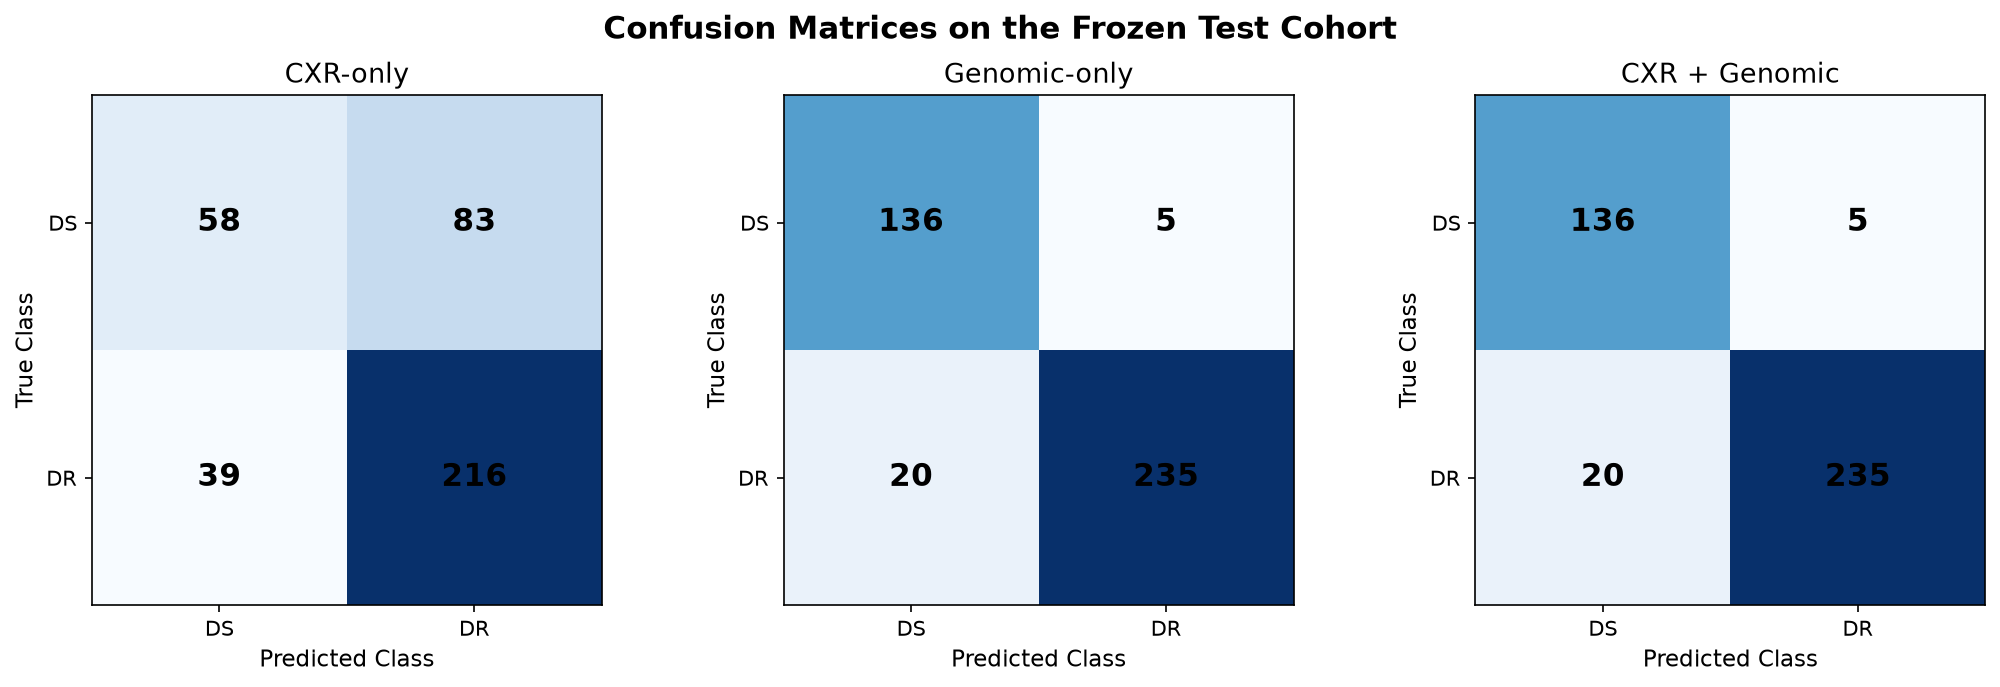

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook16_Final_Model_Comparative_Analysis\Cell4_Final_Publication_Figures\Notebook16_Cell4_Figure1_Confusion_Matrices.png

FIGURE 2 — ROC CURVES
--------------------------------------------------------------------------------


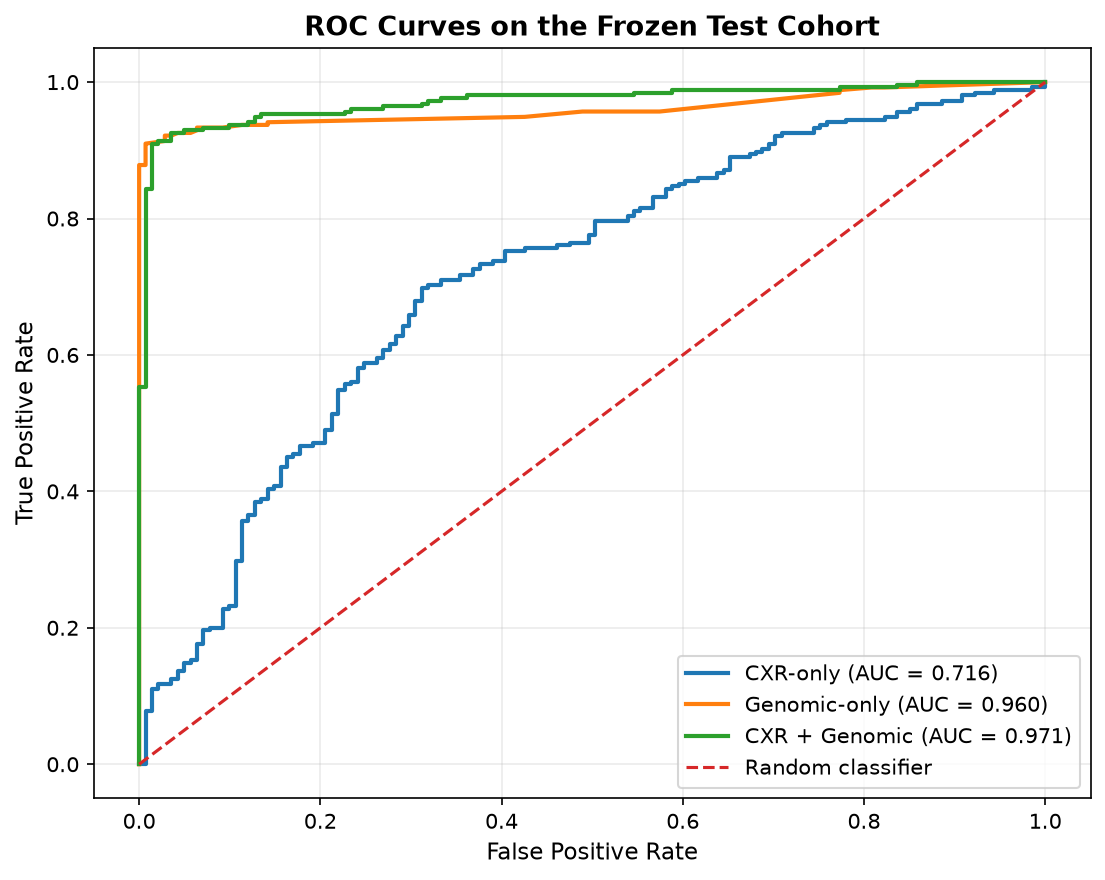

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook16_Final_Model_Comparative_Analysis\Cell4_Final_Publication_Figures\Notebook16_Cell4_Figure2_ROC_Curves.png

FIGURE 3 — PRECISION-RECALL CURVES
--------------------------------------------------------------------------------


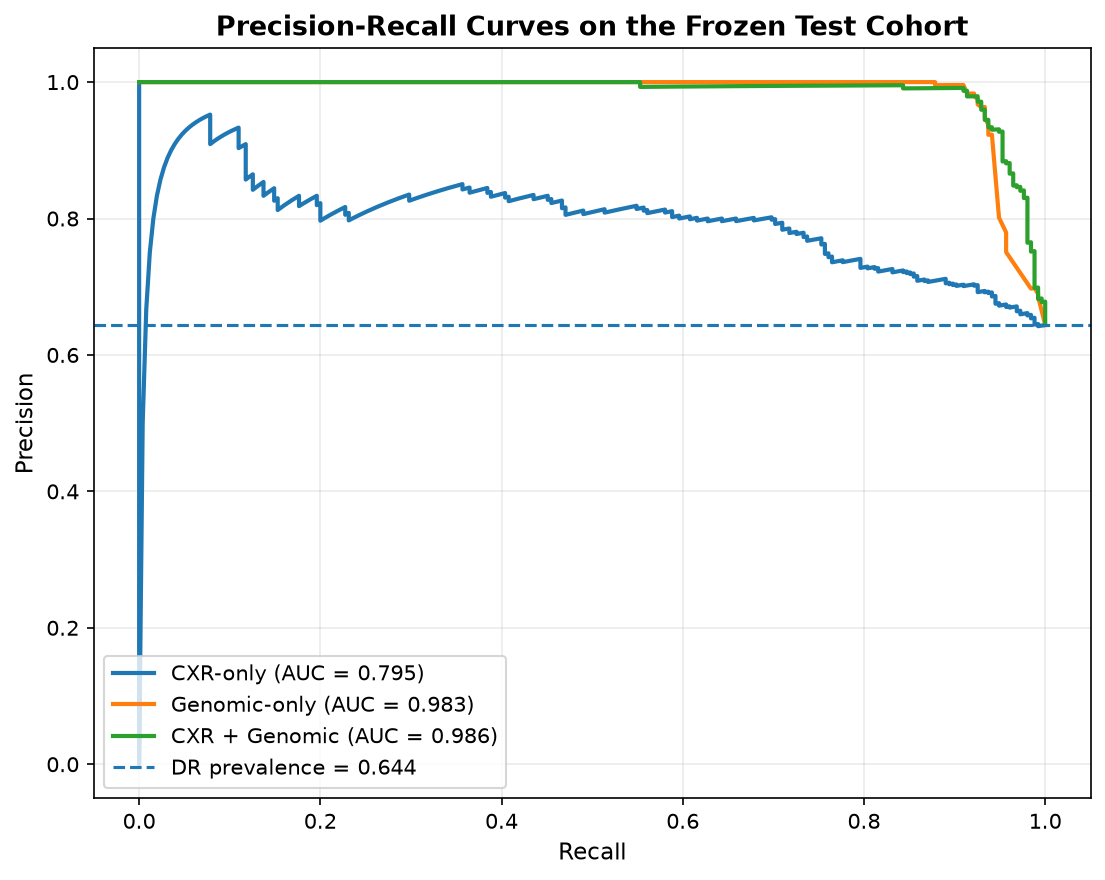

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook16_Final_Model_Comparative_Analysis\Cell4_Final_Publication_Figures\Notebook16_Cell4_Figure3_Precision_Recall_Curves.png

FIGURE 4 — MAIN PERFORMANCE COMPARISON
--------------------------------------------------------------------------------


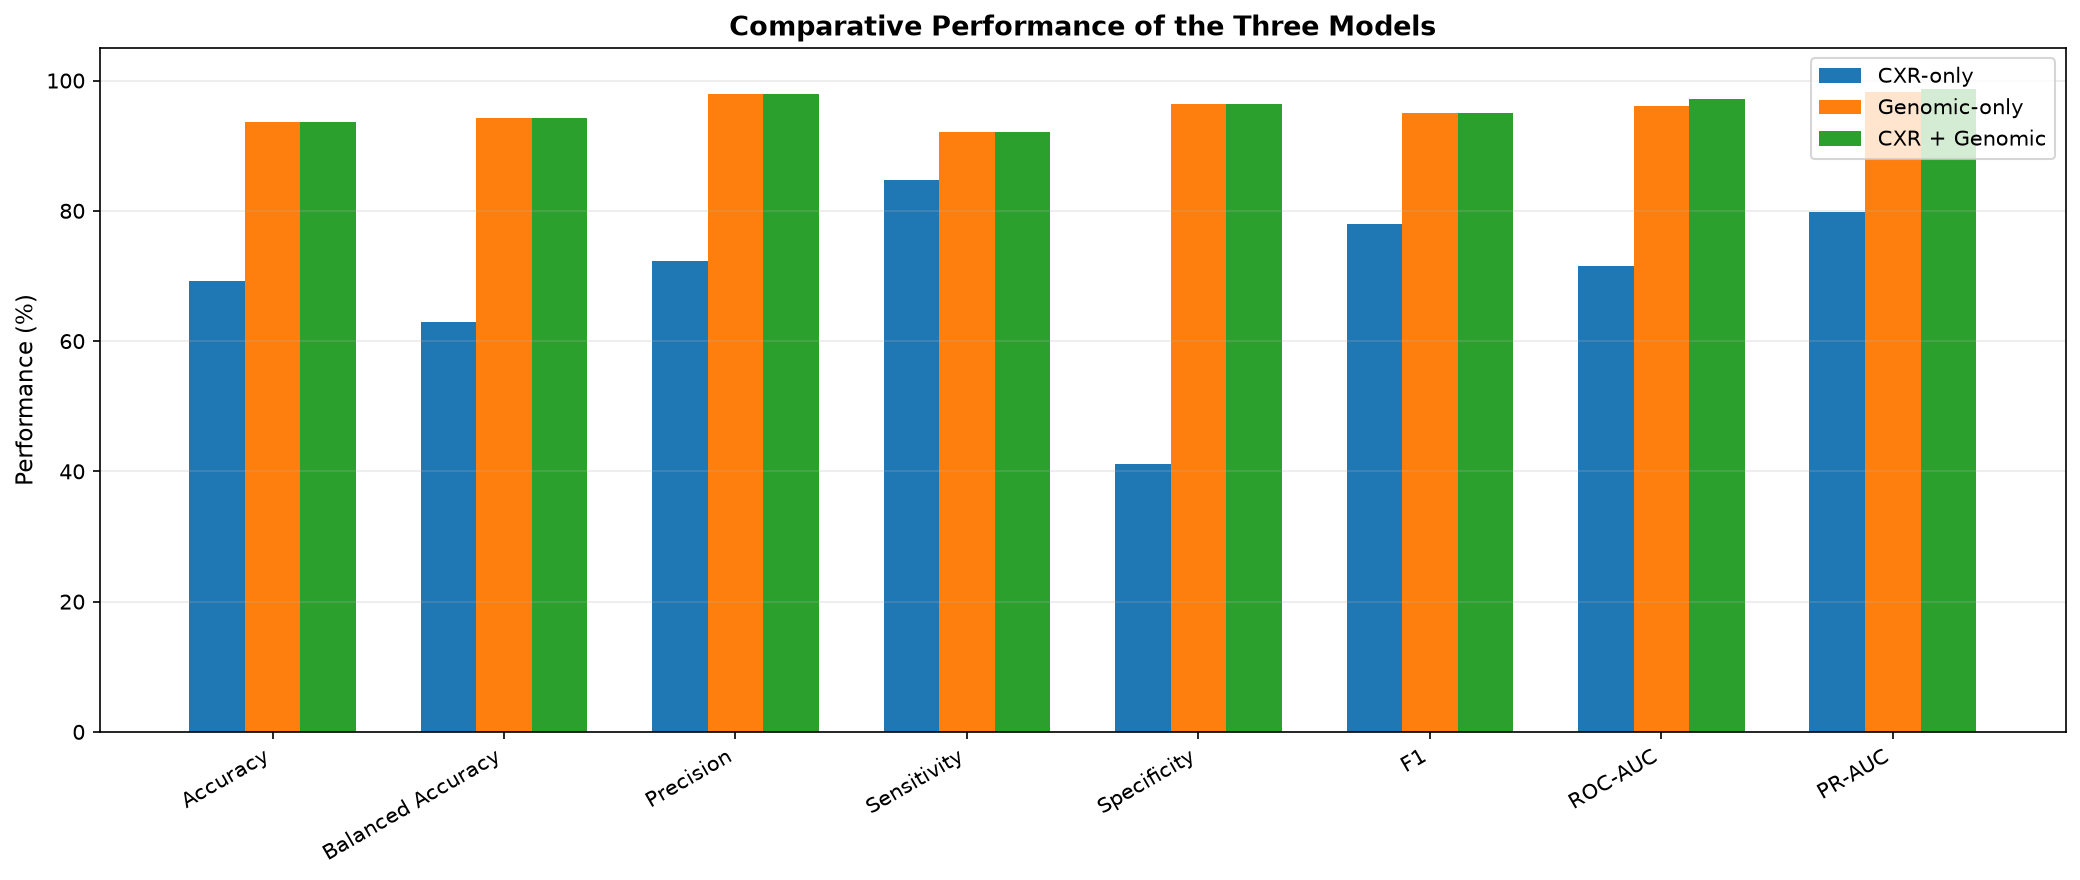

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook16_Final_Model_Comparative_Analysis\Cell4_Final_Publication_Figures\Notebook16_Cell4_Figure4_Performance_Comparison.png

FIGURE 5 — ERROR COUNTS
--------------------------------------------------------------------------------


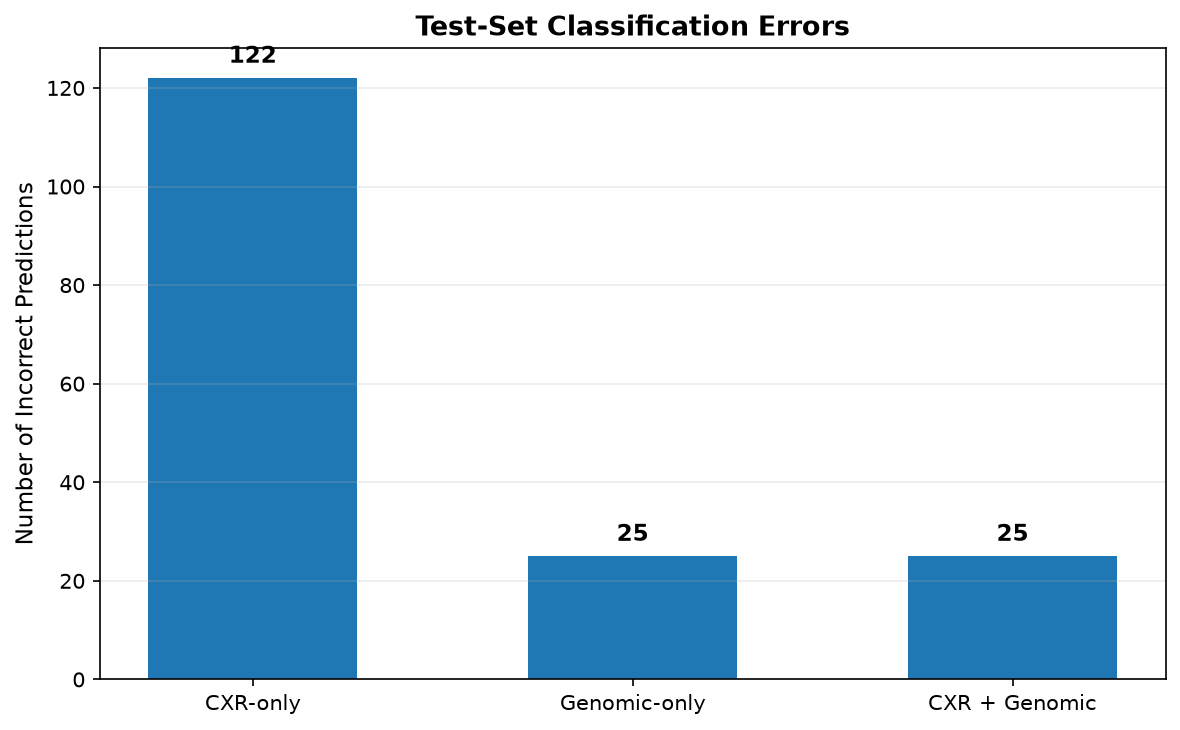

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook16_Final_Model_Comparative_Analysis\Cell4_Final_Publication_Figures\Notebook16_Cell4_Figure5_Error_Counts.png


NOTEBOOK 16 — CELL 4 STATUS: PASS
Frozen test conditions: 396
Figures generated: 5
Resolution: 600 DPI

Training performed: NO
Test inference performed: NO
Threshold tuning performed: NO
Checkpoint modified: NO

Figure directory:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook16_Final_Model_Comparative_Analysis\Cell4_Final_Publication_Figures

Figure manifest:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook16_Final_Model_Comparative_Analysis\Cell4_Final_Publication_Figures\Notebook16_Cell4_Publication_Figure_Manifest.csv

Summary:
C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\No

In [10]:
# =============================================================================
# NOTEBOOK 16 — CELL 4
# FINAL PUBLICATION FIGURES
# =============================================================================
#
# IMPORTANT:
# This cell performs visualization ONLY.
#
# NO:
#   - training
#   - inference
#   - checkpoint loading
#   - threshold tuning
#   - test-set selection
#   - modification of frozen predictions
#
# Figures:
#   1. Confusion matrices
#   2. ROC curves
#   3. Precision-Recall curves
#   4. Main performance comparison
#
# All figures use the already-frozen 396-condition test predictions.
# =============================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)


print("=" * 80)
print("NOTEBOOK 16 — CELL 4")
print("FINAL PUBLICATION FIGURES")
print("=" * 80)


# =============================================================================
# 1. PATHS
# =============================================================================

PROJECT_ROOT = Path(
    r"C:\TBP\Metadata"
)

FINAL_ROOT = (
    PROJECT_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Clean_PSPNet_CXR_Cohort"
    / "FINAL_FROZEN_CLEAN_COHORT"
)

NOTEBOOK16_ROOT = (
    FINAL_ROOT
    / "Notebook16_Final_Model_Comparative_Analysis"
)

CELL1_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell1_Cohort_Result_Audit"
)

CELL2_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell2_Paired_Statistical_Analysis"
)

CELL3_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell3_Final_Publication_Analysis"
)

CELL4_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell4_Final_Publication_Figures"
)

CELL4_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 2. INPUT FILES
# =============================================================================

PAIRED_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Paired_Test_Comparison_Data.csv"
)

METRICS_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Final_Model_Comparison_Metrics.csv"
)

CONFUSION_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Confusion_Matrices.csv"
)

CELL3_SUMMARY_FILE = (
    CELL3_ROOT
    / "Notebook16_Cell3_Final_Publication_Analysis_Summary.json"
)


# =============================================================================
# 3. PATH GATE
# =============================================================================

print("\nPATH GATE")
print("-" * 80)

required_files = {

    "Paired test data":
        PAIRED_FILE,

    "Model metrics":
        METRICS_FILE,

    "Confusion matrices":
        CONFUSION_FILE,

    "Cell 3 summary":
        CELL3_SUMMARY_FILE,

}

for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:<25}: PASS"
    )


# =============================================================================
# 4. LOAD DATA
# =============================================================================

comparison = pd.read_csv(
    PAIRED_FILE
)

metrics_df = pd.read_csv(
    METRICS_FILE
)

confusion_df = pd.read_csv(
    CONFUSION_FILE
)

with open(
    CELL3_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as f:

    cell3_summary = json.load(f)


# =============================================================================
# 5. STATUS GATE
# =============================================================================

if cell3_summary.get(
    "status"
) != "PASS":

    raise RuntimeError(
        "Notebook 16 Cell 3 did not finish with STATUS = PASS."
    )


if len(comparison) != 396:

    raise RuntimeError(
        "Expected exactly 396 frozen test conditions."
    )


print(
    "\nCell 3 status: PASS"
)

print(
    "Frozen test conditions:",
    len(comparison)
)


# =============================================================================
# 6. MODELS
# =============================================================================

MODELS = [

    "CXR-only",

    "Genomic-only",

    "CXR + Genomic",

]


# =============================================================================
# 7. EXTRACT FROZEN TEST DATA
# =============================================================================

y_true = (
    comparison[
        "cxr_target"
    ]
    .astype(int)
    .to_numpy()
)

cxr_probability = (
    comparison[
        "cxr_probability_DR"
    ]
    .astype(float)
    .to_numpy()
)

genomic_probability = (
    comparison[
        "genomic_probability_DR"
    ]
    .astype(float)
    .to_numpy()
)

multimodal_probability = (
    comparison[
        "multimodal_probability_DR"
    ]
    .astype(float)
    .to_numpy()
)


probabilities = {

    "CXR-only":
        cxr_probability,

    "Genomic-only":
        genomic_probability,

    "CXR + Genomic":
        multimodal_probability,

}


# =============================================================================
# 8. EXTRACT FROZEN PREDICTIONS
# =============================================================================

predictions = {

    "CXR-only":
        comparison[
            "cxr_prediction"
        ]
        .astype(int)
        .to_numpy(),

    "Genomic-only":
        comparison[
            "genomic_prediction"
        ]
        .astype(int)
        .to_numpy(),

    "CXR + Genomic":
        comparison[
            "multimodal_prediction"
        ]
        .astype(int)
        .to_numpy(),

}


# =============================================================================
# 9. FINAL DATA INTEGRITY CHECK
# =============================================================================

print("\nDATA INTEGRITY")
print("-" * 80)

if len(y_true) != 396:

    raise RuntimeError(
        "Incorrect number of test labels."
    )


for model_name in MODELS:

    if len(
        probabilities[model_name]
    ) != 396:

        raise RuntimeError(
            f"{model_name}: probability count mismatch."
        )

    if len(
        predictions[model_name]
    ) != 396:

        raise RuntimeError(
            f"{model_name}: prediction count mismatch."
        )


if not np.isfinite(
    y_true
).all():

    raise RuntimeError(
        "Invalid target values."
    )


for model_name in MODELS:

    p = probabilities[
        model_name
    ]

    if not np.isfinite(p).all():

        raise RuntimeError(
            f"{model_name}: non-finite probabilities."
        )

    if p.min() < 0 or p.max() > 1:

        raise RuntimeError(
            f"{model_name}: probabilities outside [0,1]."
        )


print(
    "Test conditions: 396"
)

print(
    "Targets: PASS"
)

print(
    "Probabilities: PASS"
)

print(
    "Predictions: PASS"
)

print(
    "Data integrity: PASS"
)


# =============================================================================
# 10. PUBLICATION FIGURE SETTINGS
# =============================================================================

FIG_DPI = 600

plt.rcParams.update({

    "font.size": 11,

    "axes.titlesize": 13,

    "axes.labelsize": 11,

    "xtick.labelsize": 10,

    "ytick.labelsize": 10,

    "legend.fontsize": 10,

    "figure.dpi": 150,

})


# =============================================================================
# 11. FIGURE 1 — CONFUSION MATRICES
# =============================================================================

print("\nFIGURE 1 — CONFUSION MATRICES")
print("-" * 80)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5)
)


for ax, model_name in zip(
    axes,
    MODELS
):

    row = confusion_df[
        confusion_df["Model"]
        ==
        model_name
    ]

    if len(row) != 1:

        raise RuntimeError(
            f"Confusion matrix missing for {model_name}."
        )

    row = row.iloc[0]

    tn = int(row["TN"])
    fp = int(row["FP"])
    fn = int(row["FN"])
    tp = int(row["TP"])

    matrix = np.array([

        [tn, fp],

        [fn, tp],

    ])

    image = ax.imshow(
        matrix,
        cmap="Blues"
    )

    ax.set_xticks(
        [0, 1]
    )

    ax.set_yticks(
        [0, 1]
    )

    ax.set_xticklabels(
        ["DS", "DR"]
    )

    ax.set_yticklabels(
        ["DS", "DR"]
    )

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "True Class"
    )

    ax.set_title(
        model_name
    )

    for i in range(2):

        for j in range(2):

            ax.text(
                j,
                i,
                str(matrix[i, j]),
                ha="center",
                va="center",
                fontsize=15,
                fontweight="bold"
            )


fig.suptitle(
    "Confusion Matrices on the Frozen Test Cohort",
    fontsize=15,
    fontweight="bold"
)

fig.tight_layout()

CONFUSION_FIG = (
    CELL4_ROOT
    / "Notebook16_Cell4_Figure1_Confusion_Matrices.png"
)

fig.savefig(
    CONFUSION_FIG,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    CONFUSION_FIG
)


# =============================================================================
# 12. FIGURE 2 — ROC CURVES
# =============================================================================

print("\nFIGURE 2 — ROC CURVES")
print("-" * 80)


fig, ax = plt.subplots(
    figsize=(7.5, 6)
)


for model_name in MODELS:

    probabilities_model = probabilities[
        model_name
    ]

    fpr, tpr, _ = roc_curve(
        y_true,
        probabilities_model
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {roc_auc:.3f})"
        )
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "ROC Curves on the Frozen Test Cohort",
    fontweight="bold"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

ROC_FIG = (
    CELL4_ROOT
    / "Notebook16_Cell4_Figure2_ROC_Curves.png"
)

fig.savefig(
    ROC_FIG,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    ROC_FIG
)


# =============================================================================
# 13. FIGURE 3 — PRECISION-RECALL CURVES
# =============================================================================

print("\nFIGURE 3 — PRECISION-RECALL CURVES")
print("-" * 80)


fig, ax = plt.subplots(
    figsize=(7.5, 6)
)


for model_name in MODELS:

    probabilities_model = probabilities[
        model_name
    ]

    precision, recall, _ = (
        precision_recall_curve(
            y_true,
            probabilities_model
        )
    )

    pr_auc = auc(
        recall,
        precision
    )

    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {pr_auc:.3f})"
        )
    )


positive_prevalence = (
    y_true.mean()
)


ax.axhline(
    positive_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"DR prevalence = "
        f"{positive_prevalence:.3f}"
    )
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.set_title(
    "Precision-Recall Curves on the Frozen Test Cohort",
    fontweight="bold"
)

ax.legend(
    loc="lower left"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

PR_FIG = (
    CELL4_ROOT
    / "Notebook16_Cell4_Figure3_Precision_Recall_Curves.png"
)

fig.savefig(
    PR_FIG,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    PR_FIG
)


# =============================================================================
# 14. FIGURE 4 — MAIN PERFORMANCE COMPARISON
# =============================================================================

print("\nFIGURE 4 — MAIN PERFORMANCE COMPARISON")
print("-" * 80)


metrics_to_plot = [

    "Accuracy",

    "Balanced Accuracy",

    "Precision",

    "Sensitivity",

    "Specificity",

    "F1",

    "ROC-AUC",

    "PR-AUC",

]


plot_df = metrics_df[
    ["Model"] + metrics_to_plot
].copy()


for metric in metrics_to_plot:

    plot_df[
        metric
    ] = (
        plot_df[
            metric
        ]
        * 100
    )


x = np.arange(
    len(metrics_to_plot)
)

width = 0.24


fig, ax = plt.subplots(
    figsize=(14, 6)
)


for i, model_name in enumerate(
    MODELS
):

    values = plot_df[
        plot_df["Model"]
        ==
        model_name
    ][
        metrics_to_plot
    ].iloc[0].to_numpy()

    positions = (
        x
        +
        (i - 1)
        * width
    )

    ax.bar(
        positions,
        values,
        width,
        label=model_name
    )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    metrics_to_plot,
    rotation=30,
    ha="right"
)

ax.set_ylabel(
    "Performance (%)"
)

ax.set_ylim(
    0,
    105
)

ax.set_title(
    "Comparative Performance of the Three Models",
    fontweight="bold"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

PERFORMANCE_FIG = (
    CELL4_ROOT
    / "Notebook16_Cell4_Figure4_Performance_Comparison.png"
)

fig.savefig(
    PERFORMANCE_FIG,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    PERFORMANCE_FIG
)


# =============================================================================
# 15. FIGURE 5 — MODEL ERROR COUNTS
# =============================================================================

print("\nFIGURE 5 — ERROR COUNTS")
print("-" * 80)


error_data = {

    "CXR-only":
        int(
            (
                predictions["CXR-only"]
                !=
                y_true
            ).sum()
        ),

    "Genomic-only":
        int(
            (
                predictions["Genomic-only"]
                !=
                y_true
            ).sum()
        ),

    "CXR + Genomic":
        int(
            (
                predictions["CXR + Genomic"]
                !=
                y_true
            ).sum()
        ),

}


fig, ax = plt.subplots(
    figsize=(8, 5)
)


ax.bar(
    list(error_data.keys()),
    list(error_data.values()),
    width=0.55
)

ax.set_ylabel(
    "Number of Incorrect Predictions"
)

ax.set_title(
    "Test-Set Classification Errors",
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(
    error_data.values()
):

    ax.text(
        i,
        value + 2,
        str(value),
        ha="center",
        va="bottom",
        fontweight="bold"
    )


fig.tight_layout()

ERROR_FIG = (
    CELL4_ROOT
    / "Notebook16_Cell4_Figure5_Error_Counts.png"
)

fig.savefig(
    ERROR_FIG,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    ERROR_FIG
)


# =============================================================================
# 16. FIGURE MANIFEST
# =============================================================================

figure_manifest = pd.DataFrame({

    "Figure": [

        "Figure 1",
        "Figure 2",
        "Figure 3",
        "Figure 4",
        "Figure 5",

    ],

    "Description": [

        "Confusion matrices",
        "ROC curves",
        "Precision-Recall curves",
        "Overall performance comparison",
        "Classification error counts",

    ],

    "File": [

        str(CONFUSION_FIG),
        str(ROC_FIG),
        str(PR_FIG),
        str(PERFORMANCE_FIG),
        str(ERROR_FIG),

    ],

    "DPI": [

        FIG_DPI,
        FIG_DPI,
        FIG_DPI,
        FIG_DPI,
        FIG_DPI,

    ],

})


FIGURE_MANIFEST_FILE = (
    CELL4_ROOT
    / "Notebook16_Cell4_Publication_Figure_Manifest.csv"
)

figure_manifest.to_csv(
    FIGURE_MANIFEST_FILE,
    index=False
)


# =============================================================================
# 17. CELL 4 SUMMARY
# =============================================================================

SUMMARY_FILE = (
    CELL4_ROOT
    / "Notebook16_Cell4_Publication_Figures_Summary.json"
)


summary = {

    "status":
        "PASS",

    "test_conditions":
        396,

    "models":
        MODELS,

    "figures_generated":
        5,

    "dpi":
        FIG_DPI,

    "training_performed":
        False,

    "test_inference_performed":
        False,

    "threshold_tuning_performed":
        False,

    "checkpoint_modified":
        False,

    "figures": {

        "Figure_1_Confusion_Matrices":
            str(CONFUSION_FIG),

        "Figure_2_ROC_Curves":
            str(ROC_FIG),

        "Figure_3_Precision_Recall":
            str(PR_FIG),

        "Figure_4_Performance_Comparison":
            str(PERFORMANCE_FIG),

        "Figure_5_Error_Counts":
            str(ERROR_FIG),

    },

    "figure_manifest":
        str(FIGURE_MANIFEST_FILE),

}


with open(
    SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# =============================================================================
# 18. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 16 — CELL 4 STATUS: PASS")
print("=" * 80)

print(
    "Frozen test conditions:",
    len(comparison)
)

print(
    "Figures generated:",
    5
)

print(
    "Resolution:",
    f"{FIG_DPI} DPI"
)

print(
    "\nTraining performed: NO"
)

print(
    "Test inference performed: NO"
)

print(
    "Threshold tuning performed: NO"
)

print(
    "Checkpoint modified: NO"
)

print(
    "\nFigure directory:"
)

print(
    CELL4_ROOT
)

print(
    "\nFigure manifest:"
)

print(
    FIGURE_MANIFEST_FILE
)

print(
    "\nSummary:"
)

print(
    SUMMARY_FILE
)

print(
    "\nCELL 4 COMPLETE."
)

print(
    "Next: Notebook 16 — Cell 5."
)

NOTEBOOK 16 — CELL 5
FINAL CALIBRATION + BOOTSTRAP CONFIDENCE INTERVAL ANALYSIS

PATH GATE
--------------------------------------------------------------------------------
Cell 1 paired data       : PASS
Cell 1 metrics           : PASS
Cell 1 audit             : PASS
Cell 2 summary           : PASS
Cell 3 summary           : PASS
Cell 4 summary           : PASS

Cell 1 status: PASS
Cell 2 status: PASS
Cell 3 status: PASS
Cell 4 status: PASS
Frozen test conditions: 396

DATA INTEGRITY
--------------------------------------------------------------------------------
Targets: PASS
Predictions: PASS
Probabilities: PASS

BRIER SCORE
--------------------------------------------------------------------------------
CXR-only            : 0.200204
Genomic-only        : 0.058291
CXR + Genomic       : 0.052650

EXPECTED CALIBRATION ERROR
--------------------------------------------------------------------------------
CXR-only            : ECE=0.044595
Genomic-only        : ECE=0.045296
CXR + Genomi

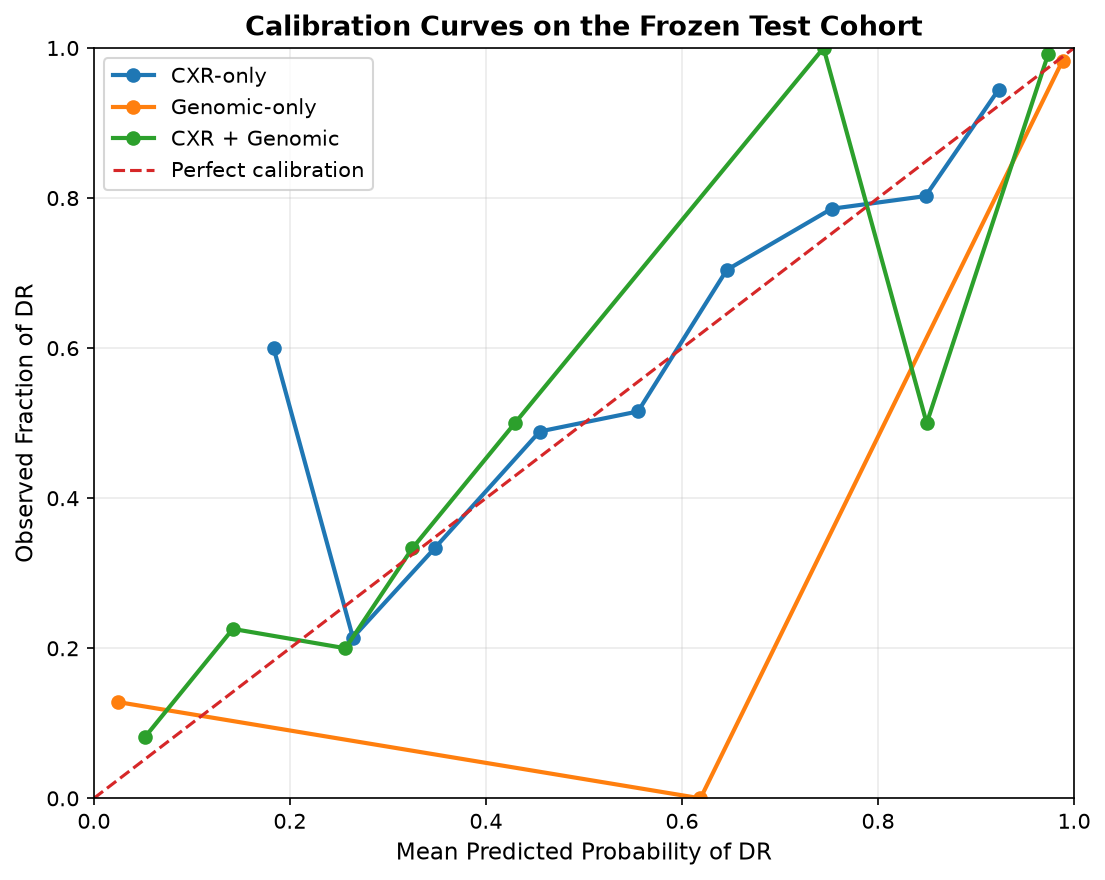

Saved: C:\TBP\Metadata\Step_3B_8_CXR_CoAtNet_Preparation\QC\Clean_PSPNet_CXR_Cohort\FINAL_FROZEN_CLEAN_COHORT\Notebook16_Final_Model_Comparative_Analysis\Cell5_Final_Calibration_Statistical_Analysis\Notebook16_Cell5_Figure1_Calibration_Curves.png

BOOTSTRAP 95% CONFIDENCE INTERVALS
--------------------------------------------------------------------------------

CXR-only
Accuracy            : 0.691919 [0.643939, 0.737374]
Balanced Accuracy   : 0.629203 [0.581514, 0.676056]
Precision           : 0.722408 [0.671140, 0.773464]
Sensitivity         : 0.847059 [0.800000, 0.889354]
Specificity         : 0.411348 [0.326079, 0.500000]
F1                  : 0.779783 [0.739923, 0.816195]
ROC-AUC             : 0.715589 [0.660445, 0.767693]
PR-AUC              : 0.797732 [0.741304, 0.854826]

Genomic-only
Accuracy            : 0.936869 [0.911616, 0.959596]
Balanced Accuracy   : 0.943054 [0.918559, 0.963857]
Precision           : 0.979167 [0.959818, 0.995745]
Sensitivity         : 0.921569 [0.884917

In [11]:
# =============================================================================
# NOTEBOOK 16 — CELL 5
# FINAL CALIBRATION + BOOTSTRAP CONFIDENCE INTERVAL ANALYSIS
# =============================================================================
#
# PURPOSE
# -------
# Final statistical quality analysis using ONLY the already-frozen test
# predictions from Notebook 16 Cells 1–4.
#
# NO:
#   - training
#   - inference
#   - checkpoint loading
#   - threshold tuning
#   - model selection
#   - modification of predictions
#
# ANALYSIS:
#   1. Brier Score
#   2. Expected Calibration Error (ECE)
#   3. Reliability / calibration curves
#   4. 95% bootstrap CIs for:
#        Accuracy
#        Balanced Accuracy
#        Precision
#        Sensitivity
#        Specificity
#        F1
#        ROC-AUC
#        PR-AUC
#   5. Final statistical consistency audit
# =============================================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve


print("=" * 80)
print("NOTEBOOK 16 — CELL 5")
print("FINAL CALIBRATION + BOOTSTRAP CONFIDENCE INTERVAL ANALYSIS")
print("=" * 80)


# =============================================================================
# 1. PATHS
# =============================================================================

PROJECT_ROOT = Path(
    r"C:\TBP\Metadata"
)

FINAL_ROOT = (
    PROJECT_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Clean_PSPNet_CXR_Cohort"
    / "FINAL_FROZEN_CLEAN_COHORT"
)

NOTEBOOK16_ROOT = (
    FINAL_ROOT
    / "Notebook16_Final_Model_Comparative_Analysis"
)

CELL1_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell1_Cohort_Result_Audit"
)

CELL2_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell2_Paired_Statistical_Analysis"
)

CELL3_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell3_Final_Publication_Analysis"
)

CELL4_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell4_Final_Publication_Figures"
)

CELL5_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell5_Final_Calibration_Statistical_Analysis"
)

CELL5_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 2. INPUT FILES
# =============================================================================

PAIRED_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Paired_Test_Comparison_Data.csv"
)

METRICS_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Final_Model_Comparison_Metrics.csv"
)

AUDIT_FILE = (
    CELL1_ROOT
    / "Notebook16_Cell1_Comparative_Analysis_Audit_Summary.json"
)

CELL2_SUMMARY_FILE = (
    CELL2_ROOT
    / "Notebook16_Cell2_Paired_Statistical_Analysis_Summary.json"
)

CELL3_SUMMARY_FILE = (
    CELL3_ROOT
    / "Notebook16_Cell3_Final_Publication_Analysis_Summary.json"
)

CELL4_SUMMARY_FILE = (
    CELL4_ROOT
    / "Notebook16_Cell4_Publication_Figures_Summary.json"
)


# =============================================================================
# 3. PATH GATE
# =============================================================================

print("\nPATH GATE")
print("-" * 80)

required_files = {

    "Cell 1 paired data":
        PAIRED_FILE,

    "Cell 1 metrics":
        METRICS_FILE,

    "Cell 1 audit":
        AUDIT_FILE,

    "Cell 2 summary":
        CELL2_SUMMARY_FILE,

    "Cell 3 summary":
        CELL3_SUMMARY_FILE,

    "Cell 4 summary":
        CELL4_SUMMARY_FILE,

}

for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"{name} not found:\n{path}"
        )

    print(
        f"{name:<25}: PASS"
    )


# =============================================================================
# 4. LOAD DATA
# =============================================================================

comparison = pd.read_csv(
    PAIRED_FILE
)

metrics_df = pd.read_csv(
    METRICS_FILE
)

with open(
    AUDIT_FILE,
    "r",
    encoding="utf-8"
) as f:

    audit_summary = json.load(f)

with open(
    CELL2_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as f:

    cell2_summary = json.load(f)

with open(
    CELL3_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as f:

    cell3_summary = json.load(f)

with open(
    CELL4_SUMMARY_FILE,
    "r",
    encoding="utf-8"
) as f:

    cell4_summary = json.load(f)


# =============================================================================
# 5. STATUS GATES
# =============================================================================

if audit_summary.get("status") != "PASS":
    raise RuntimeError(
        "Cell 1 status is not PASS."
    )

if cell2_summary.get("status") != "PASS":
    raise RuntimeError(
        "Cell 2 status is not PASS."
    )

if cell3_summary.get("status") != "PASS":
    raise RuntimeError(
        "Cell 3 status is not PASS."
    )

if cell4_summary.get("status") != "PASS":
    raise RuntimeError(
        "Cell 4 status is not PASS."
    )

if len(comparison) != 396:
    raise RuntimeError(
        "Expected exactly 396 frozen test conditions."
    )


print(
    "\nCell 1 status: PASS"
)

print(
    "Cell 2 status: PASS"
)

print(
    "Cell 3 status: PASS"
)

print(
    "Cell 4 status: PASS"
)

print(
    "Frozen test conditions:",
    len(comparison)
)


# =============================================================================
# 6. MODEL DEFINITIONS
# =============================================================================

MODELS = [

    "CXR-only",

    "Genomic-only",

    "CXR + Genomic",

]


# =============================================================================
# 7. FROZEN TARGETS
# =============================================================================

y_true = (
    comparison[
        "cxr_target"
    ]
    .astype(int)
    .to_numpy()
)


# =============================================================================
# 8. FROZEN PREDICTIONS
# =============================================================================

predictions = {

    "CXR-only":
        comparison[
            "cxr_prediction"
        ]
        .astype(int)
        .to_numpy(),

    "Genomic-only":
        comparison[
            "genomic_prediction"
        ]
        .astype(int)
        .to_numpy(),

    "CXR + Genomic":
        comparison[
            "multimodal_prediction"
        ]
        .astype(int)
        .to_numpy(),

}


# =============================================================================
# 9. FROZEN PROBABILITIES
# =============================================================================

probabilities = {

    "CXR-only":
        comparison[
            "cxr_probability_DR"
        ]
        .astype(float)
        .to_numpy(),

    "Genomic-only":
        comparison[
            "genomic_probability_DR"
        ]
        .astype(float)
        .to_numpy(),

    "CXR + Genomic":
        comparison[
            "multimodal_probability_DR"
        ]
        .astype(float)
        .to_numpy(),

}


# =============================================================================
# 10. DATA INTEGRITY
# =============================================================================

print("\nDATA INTEGRITY")
print("-" * 80)

if len(y_true) != 396:
    raise RuntimeError(
        "Target count mismatch."
    )

if set(np.unique(y_true)) != {0, 1}:
    raise RuntimeError(
        "Target must contain exactly DS=0 and DR=1."
    )

for model_name in MODELS:

    pred = predictions[
        model_name
    ]

    prob = probabilities[
        model_name
    ]

    if len(pred) != 396:
        raise RuntimeError(
            f"{model_name}: prediction count mismatch."
        )

    if len(prob) != 396:
        raise RuntimeError(
            f"{model_name}: probability count mismatch."
        )

    if not np.isfinite(prob).all():
        raise RuntimeError(
            f"{model_name}: non-finite probabilities."
        )

    if (
        prob.min() < 0
        or
        prob.max() > 1
    ):
        raise RuntimeError(
            f"{model_name}: probability outside [0,1]."
        )

    if set(np.unique(pred)) - {0, 1}:
        raise RuntimeError(
            f"{model_name}: invalid prediction values."
        )


print(
    "Targets: PASS"
)

print(
    "Predictions: PASS"
)

print(
    "Probabilities: PASS"
)


# =============================================================================
# 11. METRIC FUNCTION
# =============================================================================

def calculate_metrics(
    y,
    pred,
    prob
):

    tn = int(
        (
            (y == 0)
            &
            (pred == 0)
        ).sum()
    )

    fp = int(
        (
            (y == 0)
            &
            (pred == 1)
        ).sum()
    )

    fn = int(
        (
            (y == 1)
            &
            (pred == 0)
        ).sum()
    )

    tp = int(
        (
            (y == 1)
            &
            (pred == 1)
        ).sum()
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {

        "Accuracy":
            accuracy_score(
                y,
                pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y,
                pred
            ),

        "Precision":
            precision_score(
                y,
                pred,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(
                y,
                pred,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y,
                pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y,
                prob
            ),

        "PR-AUC":
            average_precision_score(
                y,
                prob
            ),

    }


# =============================================================================
# 12. BRIER SCORE
# =============================================================================

print("\nBRIER SCORE")
print("-" * 80)

brier_rows = []

for model_name in MODELS:

    score = brier_score_loss(
        y_true,
        probabilities[
            model_name
        ]
    )

    brier_rows.append({

        "Model":
            model_name,

        "Brier_Score":
            float(score),

    })

    print(
        f"{model_name:<20}: "
        f"{score:.6f}"
    )


brier_df = pd.DataFrame(
    brier_rows
)


# =============================================================================
# 13. ECE FUNCTION
# =============================================================================
#
# Expected Calibration Error:
#
#   ECE = sum_k (n_k / N) * |accuracy_k - confidence_k|
#
# Equal-width bins over [0,1].
# =============================================================================

def calculate_ece(
    y,
    probabilities,
    n_bins=10
):

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    bin_rows = []

    for i in range(
        n_bins
    ):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:

            mask = (
                (probabilities >= lower)
                &
                (probabilities <= upper)
            )

        else:

            mask = (
                (probabilities >= lower)
                &
                (probabilities < upper)
            )

        count = int(
            mask.sum()
        )

        if count == 0:

            bin_rows.append({

                "Bin":
                    i + 1,

                "Lower":
                    lower,

                "Upper":
                    upper,

                "Count":
                    0,

                "Mean_Confidence":
                    np.nan,

                "Observed_Frequency":
                    np.nan,

                "Absolute_Gap":
                    np.nan,

            })

            continue

        confidence = float(
            probabilities[
                mask
            ].mean()
        )

        observed_frequency = float(
            y[
                mask
            ].mean()
        )

        absolute_gap = abs(
            confidence
            -
            observed_frequency
        )

        weight = (
            count
            /
            len(y)
        )

        ece += (
            weight
            *
            absolute_gap
        )

        bin_rows.append({

            "Bin":
                i + 1,

            "Lower":
                lower,

            "Upper":
                upper,

            "Count":
                count,

            "Mean_Confidence":
                confidence,

            "Observed_Frequency":
                observed_frequency,

            "Absolute_Gap":
                absolute_gap,

        })

    return float(ece), pd.DataFrame(
        bin_rows
    )


# =============================================================================
# 14. CALCULATE ECE
# =============================================================================

print("\nEXPECTED CALIBRATION ERROR")
print("-" * 80)

ece_rows = {}

calibration_bins = {}


for model_name in MODELS:

    ece, bins = calculate_ece(
        y_true,
        probabilities[
            model_name
        ],
        n_bins=10
    )

    ece_rows[
        model_name
    ] = ece

    calibration_bins[
        model_name
    ] = bins

    print(
        f"{model_name:<20}: "
        f"ECE={ece:.6f}"
    )


ece_df = pd.DataFrame({

    "Model":
        MODELS,

    "ECE":
        [
            ece_rows[m]
            for m in MODELS
        ],

})


# =============================================================================
# 15. CALIBRATION TABLE
# =============================================================================

calibration_table_rows = []

for model_name in MODELS:

    bins = calibration_bins[
        model_name
    ].copy()

    bins.insert(
        0,
        "Model",
        model_name
    )

    calibration_table_rows.append(
        bins
    )


calibration_table_df = pd.concat(
    calibration_table_rows,
    ignore_index=True
)


# =============================================================================
# 16. CALIBRATION FIGURE
# =============================================================================

print("\nCALIBRATION FIGURE")
print("-" * 80)


fig, ax = plt.subplots(
    figsize=(7.5, 6)
)


for model_name in MODELS:

    prob = probabilities[
        model_name
    ]

    fraction_of_positives, mean_predicted_value = (
        calibration_curve(
            y_true,
            prob,
            n_bins=10,
            strategy="uniform"
        )
    )

    ax.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        linewidth=2,
        label=model_name
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)

ax.set_xlabel(
    "Mean Predicted Probability of DR"
)

ax.set_ylabel(
    "Observed Fraction of DR"
)

ax.set_title(
    "Calibration Curves on the Frozen Test Cohort",
    fontweight="bold"
)

ax.set_xlim(
    0,
    1
)

ax.set_ylim(
    0,
    1
)

ax.legend(
    loc="best"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


CALIBRATION_FIGURE = (
    CELL5_ROOT
    / "Notebook16_Cell5_Figure1_Calibration_Curves.png"
)

fig.savefig(
    CALIBRATION_FIGURE,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    CALIBRATION_FIGURE
)


# =============================================================================
# 17. BOOTSTRAP CONFIGURATION
# =============================================================================

BOOTSTRAP_N = 2000
BOOTSTRAP_SEED = 42

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


# =============================================================================
# 18. BOOTSTRAP ALL MAJOR METRICS
# =============================================================================

print("\nBOOTSTRAP 95% CONFIDENCE INTERVALS")
print("-" * 80)

metric_names = [

    "Accuracy",

    "Balanced Accuracy",

    "Precision",

    "Sensitivity",

    "Specificity",

    "F1",

    "ROC-AUC",

    "PR-AUC",

]


bootstrap_rows = []


for model_name in MODELS:

    pred = predictions[
        model_name
    ]

    prob = probabilities[
        model_name
    ]

    bootstrap_values = {
        metric: []
        for metric in metric_names
    }

    for _ in range(
        BOOTSTRAP_N
    ):

        indices = rng.integers(
            0,
            len(y_true),
            size=len(y_true)
        )

        y_boot = y_true[
            indices
        ]

        pred_boot = pred[
            indices
        ]

        prob_boot = prob[
            indices
        ]

        # ROC-AUC and PR-AUC require both classes.
        if len(
            np.unique(y_boot)
        ) < 2:

            continue

        result = calculate_metrics(
            y_boot,
            pred_boot,
            prob_boot
        )

        for metric in metric_names:

            value = result[
                metric
            ]

            if np.isfinite(value):

                bootstrap_values[
                    metric
                ].append(value)


    point_estimate = calculate_metrics(
        y_true,
        pred,
        prob
    )


    for metric in metric_names:

        values = np.asarray(
            bootstrap_values[
                metric
            ],
            dtype=np.float64
        )

        if len(values) < 1000:

            raise RuntimeError(
                f"{model_name} / {metric}: "
                f"insufficient valid bootstrap replicates "
                f"({len(values)})."
            )

        lower = float(
            np.percentile(
                values,
                2.5
            )
        )

        upper = float(
            np.percentile(
                values,
                97.5
            )
        )

        bootstrap_rows.append({

            "Model":
                model_name,

            "Metric":
                metric,

            "Point_Estimate":
                float(
                    point_estimate[
                        metric
                    ]
                ),

            "CI_95_Lower":
                lower,

            "CI_95_Upper":
                upper,

            "Bootstrap_N":
                len(values),

            "Seed":
                BOOTSTRAP_SEED,

        })


bootstrap_metrics_df = pd.DataFrame(
    bootstrap_rows
)


# =============================================================================
# 19. DISPLAY BOOTSTRAP RESULTS
# =============================================================================

for model_name in MODELS:

    print(
        f"\n{model_name}"
    )

    subset = bootstrap_metrics_df[
        bootstrap_metrics_df["Model"]
        ==
        model_name
    ]

    for _, row in subset.iterrows():

        print(
            f"{row['Metric']:<20}: "
            f"{row['Point_Estimate']:.6f} "
            f"["
            f"{row['CI_95_Lower']:.6f}, "
            f"{row['CI_95_Upper']:.6f}"
            f"]"
        )


# =============================================================================
# 20. CALIBRATION + PERFORMANCE SUMMARY
# =============================================================================

print("\nFINAL CALIBRATION SUMMARY")
print("-" * 80)

calibration_summary_df = (
    metrics_df[
        [
            "Model",
            "Accuracy",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]
    .merge(
        brier_df,
        on="Model",
        how="left",
        validate="one_to_one"
    )
    .merge(
        ece_df,
        on="Model",
        how="left",
        validate="one_to_one"
    )
)


print(
    calibration_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 21. FINAL CONSISTENCY CHECK — SAVED METRICS
# =============================================================================

print("\nFINAL METRIC CONSISTENCY CHECK")
print("-" * 80)


for model_name in MODELS:

    pred = predictions[
        model_name
    ]

    prob = probabilities[
        model_name
    ]

    calculated = calculate_metrics(
        y_true,
        pred,
        prob
    )

    saved_row = metrics_df[
        metrics_df["Model"]
        ==
        model_name
    ]

    if len(saved_row) != 1:

        raise RuntimeError(
            f"Saved metric row missing for {model_name}."
        )

    saved_row = saved_row.iloc[0]

    for metric in metric_names:

        saved_value = float(
            saved_row[
                metric
            ]
        )

        calculated_value = float(
            calculated[
                metric
            ]
        )

        if not np.isclose(
            saved_value,
            calculated_value,
            atol=1e-10
        ):

            raise RuntimeError(
                f"{model_name} / {metric} mismatch: "
                f"saved={saved_value}, "
                f"calculated={calculated_value}"
            )

    print(
        f"{model_name:<20}: PASS"
    )


# =============================================================================
# 22. FINAL CALIBRATION VALUE AUDIT
# =============================================================================

print("\nCALIBRATION VALUE AUDIT")
print("-" * 80)

for model_name in MODELS:

    brier = float(
        brier_df[
            brier_df["Model"]
            ==
            model_name
        ]["Brier_Score"].iloc[0]
    )

    ece = float(
        ece_df[
            ece_df["Model"]
            ==
            model_name
        ]["ECE"].iloc[0]
    )

    if not (
        np.isfinite(brier)
        and
        np.isfinite(ece)
    ):

        raise RuntimeError(
            f"{model_name}: invalid calibration value."
        )

    if brier < 0 or brier > 1:

        raise RuntimeError(
            f"{model_name}: invalid Brier score."
        )

    if ece < 0 or ece > 1:

        raise RuntimeError(
            f"{model_name}: invalid ECE."
        )

    print(
        f"{model_name:<20}: PASS"
    )


# =============================================================================
# 23. SAVE OUTPUTS
# =============================================================================

BRIER_FILE = (
    CELL5_ROOT
    / "Notebook16_Cell5_Brier_Scores.csv"
)

ECE_FILE = (
    CELL5_ROOT
    / "Notebook16_Cell5_ECE.csv"
)

CALIBRATION_BINS_FILE = (
    CELL5_ROOT
    / "Notebook16_Cell5_Calibration_Bins.csv"
)

BOOTSTRAP_FILE = (
    CELL5_ROOT
    / "Notebook16_Cell5_All_Metrics_Bootstrap_95CI.csv"
)

CALIBRATION_SUMMARY_FILE = (
    CELL5_ROOT
    / "Notebook16_Cell5_Calibration_Performance_Summary.csv"
)


brier_df.to_csv(
    BRIER_FILE,
    index=False
)

ece_df.to_csv(
    ECE_FILE,
    index=False
)

calibration_table_df.to_csv(
    CALIBRATION_BINS_FILE,
    index=False
)

bootstrap_metrics_df.to_csv(
    BOOTSTRAP_FILE,
    index=False
)

calibration_summary_df.to_csv(
    CALIBRATION_SUMMARY_FILE,
    index=False
)


# =============================================================================
# 24. FINAL SUMMARY JSON
# =============================================================================

SUMMARY_FILE = (
    CELL5_ROOT
    / "Notebook16_Cell5_Final_Calibration_Statistical_Summary.json"
)


summary = {

    "status":
        "PASS",

    "analysis_type":
        "Final post-test calibration and statistical analysis",

    "test_conditions":
        396,

    "test_DS":
        141,

    "test_DR":
        255,

    "models":
        MODELS,

    "bootstrap_replicates":
        BOOTSTRAP_N,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "training_performed":
        False,

    "test_inference_performed":
        False,

    "threshold_tuning_performed":
        False,

    "checkpoint_modified":
        False,

    "calibration": {

        "brier_scores":
            {
                row["Model"]:
                    float(row["Brier_Score"])
                for _, row
                in brier_df.iterrows()
            },

        "ECE":
            {
                row["Model"]:
                    float(row["ECE"])
                for _, row
                in ece_df.iterrows()
            },

    },

    "outputs": {

        "brier_scores":
            str(BRIER_FILE),

        "ECE":
            str(ECE_FILE),

        "calibration_bins":
            str(CALIBRATION_BINS_FILE),

        "bootstrap_CI":
            str(BOOTSTRAP_FILE),

        "calibration_summary":
            str(CALIBRATION_SUMMARY_FILE),

        "calibration_figure":
            str(CALIBRATION_FIGURE),

    },

}


with open(
    SUMMARY_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# =============================================================================
# 25. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 80)
print("NOTEBOOK 16 — CELL 5 STATUS: PASS")
print("=" * 80)

print(
    "Frozen test conditions:",
    396
)

print(
    "Models analyzed:",
    3
)

print(
    "Bootstrap replicates:",
    BOOTSTRAP_N
)

print(
    "Calibration figure:",
    CALIBRATION_FIGURE
)

print(
    "\nTraining performed: NO"
)

print(
    "Test inference performed: NO"
)

print(
    "Threshold tuning performed: NO"
)

print(
    "Checkpoint modified: NO"
)

print(
    "\nOutput directory:"
)

print(
    CELL5_ROOT
)

print(
    "\nSummary:"
)

print(
    SUMMARY_FILE
)

print(
    "\nCELL 5 COMPLETE."
)

print(
    "Proceed to Notebook 16 — Cell 6 only if STATUS = PASS."
)

In [12]:
# =============================================================================
# NOTEBOOK 16 — CELL 6
# FINAL CONSOLIDATED RESULTS + PUBLICATION TABLES
# =============================================================================
#
# PURPOSE
# -------
# Consolidate the complete frozen-test analysis from Notebook 16 Cells 1–5.
#
# This cell:
#   1. Loads all previously generated results.
#   2. Verifies consistency across Cells 1–5.
#   3. Creates the final main-results table.
#   4. Creates the final 95% CI table.
#   5. Creates the model-comparison table.
#   6. Creates the error-analysis table.
#   7. Creates the calibration table.
#   8. Creates a final machine-readable research summary.
#
# IMPORTANT:
#   NO TRAINING
#   NO MODEL INFERENCE
#   NO CHECKPOINT LOADING
#   NO THRESHOLD TUNING
#   NO TEST MODIFICATION
# =============================================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd


print("=" * 90)
print("NOTEBOOK 16 — CELL 6")
print("FINAL CONSOLIDATED RESULTS + PUBLICATION TABLES")
print("=" * 90)


# =============================================================================
# 1. ROOT PATHS
# =============================================================================

PROJECT_ROOT = Path(
    r"C:\TBP\Metadata"
)

FINAL_ROOT = (
    PROJECT_ROOT
    / "Step_3B_8_CXR_CoAtNet_Preparation"
    / "QC"
    / "Clean_PSPNet_CXR_Cohort"
    / "FINAL_FROZEN_CLEAN_COHORT"
)

NOTEBOOK16_ROOT = (
    FINAL_ROOT
    / "Notebook16_Final_Model_Comparative_Analysis"
)

CELL1_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell1_Cohort_Result_Audit"
)

CELL2_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell2_Paired_Statistical_Analysis"
)

CELL3_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell3_Final_Publication_Analysis"
)

CELL4_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell4_Final_Publication_Figures"
)

CELL5_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell5_Final_Calibration_Statistical_Analysis"
)

CELL6_ROOT = (
    NOTEBOOK16_ROOT
    / "Cell6_Final_Consolidated_Results"
)

CELL6_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 2. INPUT FILES
# =============================================================================

CELL1_METRICS = (
    CELL1_ROOT
    / "Notebook16_Cell1_Final_Model_Comparison_Metrics.csv"
)

CELL1_PAIRED = (
    CELL1_ROOT
    / "Notebook16_Cell1_Paired_Test_Comparison_Data.csv"
)

CELL1_SUMMARY = (
    CELL1_ROOT
    / "Notebook16_Cell1_Comparative_Analysis_Audit_Summary.json"
)

CELL2_SUMMARY = (
    CELL2_ROOT
    / "Notebook16_Cell2_Paired_Statistical_Analysis_Summary.json"
)

CELL3_SUMMARY = (
    CELL3_ROOT
    / "Notebook16_Cell3_Final_Publication_Analysis_Summary.json"
)

CELL5_BOOTSTRAP = (
    CELL5_ROOT
    / "Notebook16_Cell5_All_Metrics_Bootstrap_95CI.csv"
)

CELL5_BRIER = (
    CELL5_ROOT
    / "Notebook16_Cell5_Brier_Scores.csv"
)

CELL5_ECE = (
    CELL5_ROOT
    / "Notebook16_Cell5_ECE.csv"
)

CELL5_CALIBRATION_SUMMARY = (
    CELL5_ROOT
    / "Notebook16_Cell5_Calibration_Performance_Summary.csv"
)

CELL5_SUMMARY = (
    CELL5_ROOT
    / "Notebook16_Cell5_Final_Calibration_Statistical_Summary.json"
)


# =============================================================================
# 3. PATH VALIDATION
# =============================================================================

print("\nPATH VALIDATION")
print("-" * 90)

required_files = {

    "Cell 1 metrics":
        CELL1_METRICS,

    "Cell 1 paired data":
        CELL1_PAIRED,

    "Cell 1 summary":
        CELL1_SUMMARY,

    "Cell 2 summary":
        CELL2_SUMMARY,

    "Cell 3 summary":
        CELL3_SUMMARY,

    "Cell 5 bootstrap":
        CELL5_BOOTSTRAP,

    "Cell 5 Brier":
        CELL5_BRIER,

    "Cell 5 ECE":
        CELL5_ECE,

    "Cell 5 calibration summary":
        CELL5_CALIBRATION_SUMMARY,

    "Cell 5 summary":
        CELL5_SUMMARY,

}

for name, path in required_files.items():

    if not path.exists():

        raise FileNotFoundError(
            f"\n{name} not found:\n{path}"
        )

    print(
        f"{name:<32}: PASS"
    )


# =============================================================================
# 4. LOAD RESULTS
# =============================================================================

metrics_df = pd.read_csv(
    CELL1_METRICS
)

paired_df = pd.read_csv(
    CELL1_PAIRED
)

bootstrap_df = pd.read_csv(
    CELL5_BOOTSTRAP
)

brier_df = pd.read_csv(
    CELL5_BRIER
)

ece_df = pd.read_csv(
    CELL5_ECE
)

calibration_summary_df = pd.read_csv(
    CELL5_CALIBRATION_SUMMARY
)

with open(
    CELL1_SUMMARY,
    "r",
    encoding="utf-8"
) as f:

    cell1_summary = json.load(f)

with open(
    CELL2_SUMMARY,
    "r",
    encoding="utf-8"
) as f:

    cell2_summary = json.load(f)

with open(
    CELL3_SUMMARY,
    "r",
    encoding="utf-8"
) as f:

    cell3_summary = json.load(f)

with open(
    CELL5_SUMMARY,
    "r",
    encoding="utf-8"
) as f:

    cell5_summary = json.load(f)


# =============================================================================
# 5. STATUS GATES
# =============================================================================

print("\nSTATUS GATES")
print("-" * 90)

summaries = {

    "Cell 1":
        cell1_summary,

    "Cell 2":
        cell2_summary,

    "Cell 3":
        cell3_summary,

    "Cell 5":
        cell5_summary,

}

for name, summary in summaries.items():

    status = summary.get(
        "status"
    )

    if status != "PASS":

        raise RuntimeError(
            f"{name} status is {status}, expected PASS."
        )

    print(
        f"{name:<10}: PASS"
    )


# =============================================================================
# 6. EXPECTED MODELS
# =============================================================================

EXPECTED_MODELS = [

    "CXR-only",

    "Genomic-only",

    "CXR + Genomic",

]

actual_models = (
    metrics_df[
        "Model"
    ]
    .tolist()
)

if actual_models != EXPECTED_MODELS:

    raise RuntimeError(
        "Unexpected model ordering/content:\n"
        f"{actual_models}"
    )


# =============================================================================
# 7. FROZEN TEST COHORT AUDIT
# =============================================================================

print("\nFROZEN TEST COHORT AUDIT")
print("-" * 90)

if len(paired_df) != 396:

    raise RuntimeError(
        f"Expected 396 test rows, found {len(paired_df)}."
    )

if paired_df[
    "condition_id"
].nunique() != 396:

    raise RuntimeError(
        "Condition IDs are not unique."
    )


# Determine target column robustly.

target_candidates = [

    "target_binary",

    "cxr_target",

]

target_col = None

for col in target_candidates:

    if col in paired_df.columns:

        target_col = col

        break

if target_col is None:

    raise RuntimeError(
        "Could not locate target column."
    )


y = (
    paired_df[
        target_col
    ]
    .astype(int)
)


if set(
    y.unique()
) != {0, 1}:

    raise RuntimeError(
        "Target does not contain DS=0 and DR=1."
    )


n_ds = int(
    (y == 0).sum()
)

n_dr = int(
    (y == 1).sum()
)


if n_ds != 141 or n_dr != 255:

    raise RuntimeError(
        f"Unexpected test distribution: "
        f"DS={n_ds}, DR={n_dr}"
    )


print(
    "Test conditions       : 396"
)

print(
    "DS conditions         : 141"
)

print(
    "DR conditions         : 255"
)

print(
    "Condition uniqueness  : PASS"
)


# =============================================================================
# 8. FINAL MAIN RESULTS TABLE
# =============================================================================

print("\nFINAL MAIN RESULTS")
print("-" * 90)

main_columns = [

    "Model",

    "Accuracy",

    "Balanced Accuracy",

    "Precision",

    "Sensitivity",

    "Specificity",

    "F1",

    "ROC-AUC",

    "PR-AUC",

]

missing = [
    c for c in main_columns
    if c not in metrics_df.columns
]

if missing:

    raise RuntimeError(
        f"Missing metric columns: {missing}"
    )


main_results = (
    metrics_df[
        main_columns
    ]
    .copy()
)


print(
    main_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 9. PUBLICATION-FORMATTED MAIN TABLE
# =============================================================================

publication_main = main_results.copy()

for column in main_columns[1:]:

    publication_main[
        column
    ] = publication_main[
        column
    ].map(
        lambda x: f"{x * 100:.2f}"
    )


publication_main.rename(
    columns={

        "Accuracy":
            "Accuracy (%)",

        "Balanced Accuracy":
            "Balanced Accuracy (%)",

        "Precision":
            "Precision (%)",

        "Sensitivity":
            "Sensitivity (%)",

        "Specificity":
            "Specificity (%)",

        "F1":
            "F1 (%)",

        "ROC-AUC":
            "ROC-AUC (%)",

        "PR-AUC":
            "PR-AUC (%)",

    },
    inplace=True
)


# =============================================================================
# 10. 95% CI TABLE
# =============================================================================

print("\nBOOTSTRAP 95% CI TABLE")
print("-" * 90)

ci_wide_rows = []

for model_name in EXPECTED_MODELS:

    subset = bootstrap_df[
        bootstrap_df["Model"]
        ==
        model_name
    ]

    row = {
        "Model":
            model_name
    }

    for _, r in subset.iterrows():

        metric = r[
            "Metric"
        ]

        row[
            metric
        ] = (
            f"{r['Point_Estimate'] * 100:.2f}% "
            f"("
            f"{r['CI_95_Lower'] * 100:.2f}–"
            f"{r['CI_95_Upper'] * 100:.2f}"
            f")"
        )

    ci_wide_rows.append(
        row
    )


ci_publication_df = pd.DataFrame(
    ci_wide_rows
)

print(
    ci_publication_df.to_string(
        index=False
    )
)


# =============================================================================
# 11. CALIBRATION TABLE
# =============================================================================

print("\nCALIBRATION RESULTS")
print("-" * 90)

calibration_publication = (
    brier_df[
        [
            "Model",
            "Brier_Score"
        ]
    ]
    .merge(
        ece_df[
            [
                "Model",
                "ECE"
            ]
        ],
        on="Model",
        how="inner",
        validate="one_to_one"
    )
)

print(
    calibration_publication.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 12. ERROR ANALYSIS TABLE
# =============================================================================

print("\nERROR ANALYSIS")
print("-" * 90)


def get_prediction_column(
    model
):

    candidates = {

        "CXR-only": [
            "cxr_prediction",
            "cxr_predicted_binary",
        ],

        "Genomic-only": [
            "genomic_prediction",
            "genomic_predicted_binary",
        ],

        "CXR + Genomic": [
            "multimodal_prediction",
            "multimodal_predicted_binary",
        ],

    }

    for column in candidates[
        model
    ]:

        if column in paired_df.columns:

            return column

    raise RuntimeError(
        f"Prediction column not found for {model}."
    )


error_rows = []


for model_name in EXPECTED_MODELS:

    pred_col = get_prediction_column(
        model_name
    )

    pred = (
        paired_df[
            pred_col
        ]
        .astype(int)
    )

    errors = (
        pred
        !=
        y
    )

    ds_errors = int(
        errors[
            y == 0
        ].sum()
    )

    dr_errors = int(
        errors[
            y == 1
        ].sum()
    )

    total_errors = int(
        errors.sum()
    )

    correct = int(
        (~errors).sum()
    )

    error_rows.append({

        "Model":
            model_name,

        "Correct":
            correct,

        "Total Errors":
            total_errors,

        "DS Errors":
            ds_errors,

        "DR Errors":
            dr_errors,

        "Accuracy":
            correct / len(y),

    })


error_df = pd.DataFrame(
    error_rows
)

print(
    error_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# =============================================================================
# 13. HARD-PREDICTION AGREEMENT
# =============================================================================

print("\nHARD-PREDICTION AGREEMENT")
print("-" * 90)


prediction_arrays = {}

for model_name in EXPECTED_MODELS:

    prediction_arrays[
        model_name
    ] = (
        paired_df[
            get_prediction_column(
                model_name
            )
        ]
        .astype(int)
        .to_numpy()
    )


for i in range(
    len(EXPECTED_MODELS)
):

    for j in range(
        i + 1,
        len(EXPECTED_MODELS)
    ):

        model_a = EXPECTED_MODELS[i]
        model_b = EXPECTED_MODELS[j]

        agreement = int(
            (
                prediction_arrays[
                    model_a
                ]
                ==
                prediction_arrays[
                    model_b
                ]
            ).sum()
        )

        percentage = (
            agreement
            /
            len(y)
            *
            100
        )

        print(
            f"{model_a} vs {model_b}: "
            f"{agreement}/{len(y)} "
            f"({percentage:.2f}%)"
        )


# =============================================================================
# 14. KEY DELTAS
# =============================================================================

print("\nKEY PERFORMANCE DELTAS")
print("-" * 90)


metric_delta_rows = []

for metric in [

    "Accuracy",

    "Balanced Accuracy",

    "Precision",

    "Sensitivity",

    "Specificity",

    "F1",

    "ROC-AUC",

    "PR-AUC",

]:

    cxr_value = float(
        metrics_df[
            metrics_df["Model"]
            ==
            "CXR-only"
        ][metric].iloc[0]
    )

    genomic_value = float(
        metrics_df[
            metrics_df["Model"]
            ==
            "Genomic-only"
        ][metric].iloc[0]
    )

    multimodal_value = float(
        metrics_df[
            metrics_df["Model"]
            ==
            "CXR + Genomic"
        ][metric].iloc[0]
    )

    metric_delta_rows.append({

        "Metric":
            metric,

        "Genomic_vs_CXR_pp":
            (genomic_value - cxr_value) * 100,

        "Multimodal_vs_CXR_pp":
            (multimodal_value - cxr_value) * 100,

        "Multimodal_vs_Genomic_pp":
            (multimodal_value - genomic_value) * 100,

    })


delta_df = pd.DataFrame(
    metric_delta_rows
)

print(
    delta_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# =============================================================================
# 15. CONSISTENCY CHECK — GENOMIC VS MULTIMODAL
# =============================================================================

print("\nGENOMIC VS MULTIMODAL CONSISTENCY")
print("-" * 90)

genomic_pred = prediction_arrays[
    "Genomic-only"
]

multimodal_pred = prediction_arrays[
    "CXR + Genomic"
]

hard_prediction_difference = int(
    (
        genomic_pred
        !=
        multimodal_pred
    ).sum()
)

if hard_prediction_difference != 0:

    raise RuntimeError(
        "Genomic-only and multimodal hard predictions "
        "are unexpectedly different."
    )

print(
    "Hard prediction differences:",
    hard_prediction_difference
)

print(
    "Hard prediction agreement  : 100.00%"
)


# =============================================================================
# 16. FINAL RESEARCH FACTS
# =============================================================================

cxr_accuracy = float(
    metrics_df[
        metrics_df["Model"]
        ==
        "CXR-only"
    ]["Accuracy"].iloc[0]
)

genomic_accuracy = float(
    metrics_df[
        metrics_df["Model"]
        ==
        "Genomic-only"
    ]["Accuracy"].iloc[0]
)

multimodal_accuracy = float(
    metrics_df[
        metrics_df["Model"]
        ==
        "CXR + Genomic"
    ]["Accuracy"].iloc[0]
)

cxr_auc = float(
    metrics_df[
        metrics_df["Model"]
        ==
        "CXR-only"
    ]["ROC-AUC"].iloc[0]
)

genomic_auc = float(
    metrics_df[
        metrics_df["Model"]
        ==
        "Genomic-only"
    ]["ROC-AUC"].iloc[0]
)

multimodal_auc = float(
    metrics_df[
        metrics_df["Model"]
        ==
        "CXR + Genomic"
    ]["ROC-AUC"].iloc[0]
)


# =============================================================================
# 17. FINAL CONSOLIDATED SUMMARY
# =============================================================================

final_summary = {

    "status":
        "PASS",

    "analysis_scope":
        "Frozen-test comparative analysis",

    "test_cohort": {

        "conditions":
            396,

        "DS":
            141,

        "DR":
            255,

        "target_encoding":
            {
                "DS": 0,
                "DR": 1
            },

    },

    "models": {

        "CXR-only": {

            "accuracy":
                cxr_accuracy,

            "ROC-AUC":
                cxr_auc,

        },

        "Genomic-only": {

            "accuracy":
                genomic_accuracy,

            "ROC-AUC":
                genomic_auc,

        },

        "CXR + Genomic": {

            "accuracy":
                multimodal_accuracy,

            "ROC-AUC":
                multimodal_auc,

        },

    },

    "important_observations": {

        "genomic_accuracy_gain_over_CXR_percentage_points":
            (
                genomic_accuracy
                -
                cxr_accuracy
            ) * 100,

        "multimodal_accuracy_gain_over_CXR_percentage_points":
            (
                multimodal_accuracy
                -
                cxr_accuracy
            ) * 100,

        "multimodal_ROC_AUC_gain_over_genomic_percentage_points":
            (
                multimodal_auc
                -
                genomic_auc
            ) * 100,

        "genomic_multimodal_hard_prediction_agreement":
            1.0,

    },

    "test_isolation": {

        "training_performed":
            False,

        "test_inference_performed_in_cell6":
            False,

        "threshold_tuning":
            False,

        "checkpoint_selection_from_test":
            False,

        "checkpoint_modified":
            False,

    },

    "outputs_directory":
        str(CELL6_ROOT),

}


# =============================================================================
# 18. SAVE FINAL TABLES
# =============================================================================

MAIN_TABLE_FILE = (
    CELL6_ROOT
    / "Notebook16_Cell6_Table1_Final_Main_Performance.csv"
)

CI_TABLE_FILE = (
    CELL6_ROOT
    / "Notebook16_Cell6_Table2_Final_95CI.csv"
)

CALIBRATION_TABLE_FILE = (
    CELL6_ROOT
    / "Notebook16_Cell6_Table3_Final_Calibration.csv"
)

ERROR_TABLE_FILE = (
    CELL6_ROOT
    / "Notebook16_Cell6_Table4_Final_Error_Analysis.csv"
)

DELTA_TABLE_FILE = (
    CELL6_ROOT
    / "Notebook16_Cell6_Table5_Final_Performance_Deltas.csv"
)

SUMMARY_JSON_FILE = (
    CELL6_ROOT
    / "Notebook16_Cell6_Final_Research_Summary.json"
)


publication_main.to_csv(
    MAIN_TABLE_FILE,
    index=False
)

ci_publication_df.to_csv(
    CI_TABLE_FILE,
    index=False
)

calibration_publication.to_csv(
    CALIBRATION_TABLE_FILE,
    index=False
)

error_df.to_csv(
    ERROR_TABLE_FILE,
    index=False
)

delta_df.to_csv(
    DELTA_TABLE_FILE,
    index=False
)


with open(
    SUMMARY_JSON_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_summary,
        f,
        indent=4
    )


# =============================================================================
# 19. FINAL OUTPUT MANIFEST
# =============================================================================

manifest = pd.DataFrame({

    "Output": [

        "Final Main Performance Table",

        "Final 95% CI Table",

        "Final Calibration Table",

        "Final Error Analysis Table",

        "Final Performance Delta Table",

        "Final Research Summary",

    ],

    "Path": [

        str(MAIN_TABLE_FILE),

        str(CI_TABLE_FILE),

        str(CALIBRATION_TABLE_FILE),

        str(ERROR_TABLE_FILE),

        str(DELTA_TABLE_FILE),

        str(SUMMARY_JSON_FILE),

    ],

})

MANIFEST_FILE = (
    CELL6_ROOT
    / "Notebook16_Cell6_Output_Manifest.csv"
)

manifest.to_csv(
    MANIFEST_FILE,
    index=False
)


# =============================================================================
# 20. FINAL STATUS
# =============================================================================

print("\n")
print("=" * 90)
print("NOTEBOOK 16 — CELL 6 STATUS: PASS")
print("=" * 90)

print(
    "\nFinal frozen test cohort:"
)

print(
    "396 conditions | DS=141 | DR=255"
)

print(
    "\nFinal model accuracies:"
)

print(
    f"CXR-only       : {cxr_accuracy * 100:.2f}%"
)

print(
    f"Genomic-only   : {genomic_accuracy * 100:.2f}%"
)

print(
    f"CXR + Genomic  : {multimodal_accuracy * 100:.2f}%"
)

print(
    "\nFinal ROC-AUC:"
)

print(
    f"CXR-only       : {cxr_auc:.6f}"
)

print(
    f"Genomic-only   : {genomic_auc:.6f}"
)

print(
    f"CXR + Genomic  : {multimodal_auc:.6f}"
)

print(
    "\nTraining performed in Cell 6: NO"
)

print(
    "Test inference performed in Cell 6: NO"
)

print(
    "Threshold tuning performed: NO"
)

print(
    "Checkpoint modification: NO"
)

print(
    "\nAll final publication tables saved to:"
)

print(
    CELL6_ROOT
)

print(
    "\nFinal summary:"
)

print(
    SUMMARY_JSON_FILE
)

print(
    "\nCELL 6 COMPLETE."
)

NOTEBOOK 16 — CELL 6
FINAL CONSOLIDATED RESULTS + PUBLICATION TABLES

PATH VALIDATION
------------------------------------------------------------------------------------------
Cell 1 metrics                  : PASS
Cell 1 paired data              : PASS
Cell 1 summary                  : PASS
Cell 2 summary                  : PASS
Cell 3 summary                  : PASS
Cell 5 bootstrap                : PASS
Cell 5 Brier                    : PASS
Cell 5 ECE                      : PASS
Cell 5 calibration summary      : PASS
Cell 5 summary                  : PASS

STATUS GATES
------------------------------------------------------------------------------------------
Cell 1    : PASS
Cell 2    : PASS
Cell 3    : PASS
Cell 5    : PASS

FROZEN TEST COHORT AUDIT
------------------------------------------------------------------------------------------
Test conditions       : 396
DS conditions         : 141
DR conditions         : 255
Condition uniqueness  : PASS

FINAL MAIN RESULTS
----------